In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
local_path = 'E:/Study/HICT_Patterns/'

# Results for article

## Comaparison with EagleC2, mono weights, mono inference

In [23]:
mono_results = {}

#### Pipeline

In [66]:
mono_results['pipeline'] = {}

for label, result_path, answers_path in zip(['B orangutan', 'Gor', 'S orangutan', 'Pan troglodytes', 'Siamang', 'Bonobo'],
                                         ['B_orangutan_detected_breakpoints.csv', 'gor_detected_breakpoints.csv', 'S_orangutan_detected_breakpoints.csv', 'Pan_troglodytes_detected_breakpoints.csv', 'Siamang_Chm_detected_breakpoints.csv', 'bonobo_detected_breakpoints.csv'],
                                         ['filtered_B_orangutan_Chm_SVs', 'filtered_Gor_Chm_SVs', 'filtered_S_orangutan_Chm_SVs', 'filtered_Pan_troglodytes_Chm_SVs', 'filtered_Siamang_Chm_SVs', 'filtered_bonobo_Chm_SVs']):

    results = pd.read_csv(f"{local_path}logs/pipeline_results/{result_path}")
    results = results[np.abs(results['x'] - results['y']) > 5*1000000]
    results.reset_index(inplace=True)
    result_res = 1
    image_size = 48
    hited_results = np.zeros(results.shape[0])


    answers = pd.read_csv(f"{local_path}data/apes/answers/{answers_path}.csv")
    answers = answers[np.abs(answers['start'] - answers['end']) > 5*1000000]
    answers.reset_index(inplace=True)
    hited_answers = np.zeros(answers.shape[0]*2)
    for i, ans in answers.iterrows():
        chr_res = results[results['chr']==ans['chr']]
        for i_x, res in chr_res.iterrows():
            if abs(res['x']-ans['end']) <=48*50000 or abs(res['y']-ans['end']) <=48*50000:
                hited_answers[i] = 1
                hited_results[i_x]=1
            if abs(res['y']-ans['start']) <=48*50000 or abs(res['x']-ans['start']) <=48*50000:
                hited_answers[i+answers.shape[0]] = 1
                hited_results[i_x]=1

    precision = sum(hited_results)/len(hited_results)
    recall = sum(hited_answers)/(len(hited_answers))
    f1_score = (2 * precision * recall)/(precision+recall)
    print(f'\n=============={label}==========================')
    print(f'TP: {sum(hited_results)}')
    print(f'Total bp repotred count: {len(hited_results)}')
    print(f'Precision: {precision}')
    print(f'Found {sum(hited_answers)} from {len(hited_answers)} breakpoints')
    print(f'Recall: {recall}')
    print(f'F1 Score: {f1_score}')
    print('===================================================\n')

    mono_results['pipeline'][label] = {
        'precision':precision,
        'recall':recall,
        'f1_score':f1_score
    }


==============B orangutan==========================
TP: 14.0
Total bp repotred count: 58
Precision: 0.2413793103448276
Found 5.0 from 8 breakpoints
Recall: 0.625
F1 Score: 0.34825870646766166


==============Gor==========================
TP: 46.0
Total bp repotred count: 163
Precision: 0.2822085889570552
Found 10.0 from 10 breakpoints
Recall: 1.0
F1 Score: 0.44019138755980863


==============S orangutan==========================
TP: 81.0
Total bp repotred count: 426
Precision: 0.19014084507042253
Found 13.0 from 14 breakpoints
Recall: 0.9285714285714286
F1 Score: 0.31564748201438847


==============Pan troglodytes==========================
TP: 158.0
Total bp repotred count: 1209
Precision: 0.130686517783292
Found 8.0 from 8 breakpoints
Recall: 1.0
F1 Score: 0.23116313094367227


==============Siamang==========================
TP: 13.0
Total bp repotred count: 1676
Precision: 0.007756563245823389
Found 2.0 from 2 breakpoints
Recall: 1.0
F1 Score: 0.015393724097098873


==============Bo

#### EagleC2

In [65]:
mono_results['eaglec'] = {}

for label, result_path, answers_path in zip(['B orangutan', 'Gor', 'S orangutan', 'Pan troglodytes', 'Siamang', 'Bonobo'],
                                         ['B_orangutan_eaglec.SV_calls', 'Gor_Chm_eaglec.SV_calls', 'S_orangutan_Chm_eaglec.SV_calls', 'Pan_troglodytes_Chm_eaglec.SV_calls', 'Siamang_Chm_eaglec.SV_calls', 'Bonobo_Chm_eaglec.SV_calls'],
                                         ['filtered_B_orangutan_Chm_SVs', 'filtered_Gor_Chm_SVs', 'filtered_S_orangutan_Chm_SVs', 'filtered_Pan_troglodytes_Chm_SVs', 'filtered_Siamang_Chm_SVs', 'filtered_bonobo_Chm_SVs']):


    eaglec_results = pd.read_csv(f'{local_path}logs/eaglec_results/{result_path}.txt', sep='\t')
    eaglec_results = eaglec_results[eaglec_results['chrom1'] == eaglec_results['chrom2']]

    eaglec_results = eaglec_results[np.abs(eaglec_results['pos1'] - eaglec_results['pos2']) > 5*1000000]
    eaglec_results.reset_index(inplace=True)
    result_res = 1
    image_size = 48
    hited_results = np.zeros(eaglec_results.shape[0])


    answers = pd.read_csv(f"{local_path}data/apes/answers/{answers_path}.csv")
    answers = answers[np.abs(answers['start'] - answers['end']) > 5*1000000]
    answers.reset_index(inplace=True)
    hited_answers = np.zeros(answers.shape[0]*2)
    for i, ans in answers.iterrows():
        chr_res = eaglec_results[eaglec_results['chrom1']==ans['chr']]
        for i_x, res in chr_res.iterrows():
            if abs(res['pos1']-ans['end']) <=48*50000 or abs(res['pos2']-ans['end']) <=48*50000:
                hited_answers[i] = 1
                hited_results[i_x]=1
            if abs(res['pos2']-ans['start']) <=48*50000 or abs(res['pos1']-ans['start']) <=48*50000:
                hited_answers[i+answers.shape[0]] = 1
                hited_results[i_x]=1

    precision = sum(hited_results)/len(hited_results)
    recall = sum(hited_answers)/(len(hited_answers))
    f1_score = (2 * precision * recall)/(precision+recall)
    print(f'\n=============={label}==========================')
    print(f'TP: {sum(hited_results)}')
    print(f'Total bp repotred count: {len(hited_results)}')
    print(f'Precision: {precision}')
    print(f'Found {sum(hited_answers)} from {len(hited_answers)} breakpoints')
    print(f'Recall: {recall}')
    print(f'F1 Score: {f1_score}')
    print('===================================================\n')

    mono_results['eaglec'][label] = {
        'precision':precision,
        'recall':recall,
        'f1_score':f1_score
    }


==============B orangutan==========================
TP: 89.0
Total bp repotred count: 752
Precision: 0.11835106382978723
Found 7.0 from 8 breakpoints
Recall: 0.875
F1 Score: 0.20850066934404285


==============Gor==========================
TP: 65.0
Total bp repotred count: 938
Precision: 0.06929637526652452
Found 10.0 from 10 breakpoints
Recall: 1.0
F1 Score: 0.1296111665004985


==============S orangutan==========================
TP: 153.0
Total bp repotred count: 857
Precision: 0.17852975495915985
Found 14.0 from 14 breakpoints
Recall: 1.0
F1 Score: 0.30297029702970296


==============Pan troglodytes==========================
TP: 16.0
Total bp repotred count: 289
Precision: 0.05536332179930796
Found 8.0 from 8 breakpoints
Recall: 1.0
F1 Score: 0.10491803278688526


==============Siamang==========================
TP: 0.0
Total bp repotred count: 743
Precision: 0.0
Found 0.0 from 2 breakpoints
Recall: 0.0
F1 Score: nan


==============Bonobo==========================
TP: 54.0
Total bp

C:\Users\vit\AppData\Local\Temp\ipykernel_15992\3872723677.py:34: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = (2 * precision * recall)/(precision+recall)


## Comparison of transition learning

### Train on one and inference on another

In [47]:
trans_results = {}

for label, result_path, answers_path in zip(['B orangutan by Gor', 'Gor by B orangutan', 'S orangutan by Pan troglodytes', 'Pan troglodytes by S orangutan', 'Siamang by Bonobo', 'Bonobo by Siamang'],
                                         ['B_orangutan_by_Gor_weights_detected_breakpoints', 'Gor_Chm_by_B_orangutan_weights_detected_breakpoints', 'S_orangutan_Chm_by_Pan_troglodytes_weights_detected_breakpoints', 'Pan_troglodytes_Chm_by_S_orangutan_weights_detected_breakpoints', 'Siamang_Chm_by_Bonobo_weights_detected_breakpoints', 'Bonobo_Chm_by_Siamang_weights_detected_breakpoints'],
                                         ['filtered_B_orangutan_Chm_SVs', 'filtered_Gor_Chm_SVs', 'filtered_S_orangutan_Chm_SVs', 'filtered_Pan_troglodytes_Chm_SVs', 'filtered_Siamang_Chm_SVs', 'filtered_bonobo_Chm_SVs']):

    results = pd.read_csv(f"{local_path}logs/pipeline_results/transfer_learning/{result_path}.csv")
    results = results[np.abs(results['x'] - results['y']) > 5*1000000]
    results.reset_index(inplace=True)
    result_res = 1
    image_size = 48
    hited_results = np.zeros(results.shape[0])


    answers = pd.read_csv(f"{local_path}data/apes/answers/{answers_path}.csv")
    answers = answers[np.abs(answers['start'] - answers['end']) > 5*1000000]
    answers.reset_index(inplace=True)
    hited_answers = np.zeros(answers.shape[0]*2)
    for i, ans in answers.iterrows():
        chr_res = results[results['chr']==ans['chr']]
        for i_x, res in chr_res.iterrows():
            if abs(res['x']-ans['end']) <=48*50000 or abs(res['y']-ans['end']) <=48*50000:
                hited_answers[i] = 1
                hited_results[i_x]=1
            if abs(res['y']-ans['start']) <=48*50000 or abs(res['x']-ans['start']) <=48*50000:
                hited_answers[i+answers.shape[0]] = 1
                hited_results[i_x]=1

    precision = sum(hited_results)/len(hited_results)
    recall = sum(hited_answers)/(len(hited_answers))
    f1_score = (2 * precision * recall)/(precision+recall)
    print(f'\n=============={label}==========================')
    print(f'TP: {sum(hited_results)}')
    print(f'Total bp repotred count: {len(hited_results)}')
    print(f'Precision: {precision}')
    print(f'Found {sum(hited_answers)} from {len(hited_answers)} breakpoints')
    print(f'Recall: {recall}')
    print(f'F1 Score: {f1_score}')
    print('===================================================\n')

    trans_results[label] = {
        'precision':precision,
        'recall':recall,
        'f1_score':f1_score
    }


==============B orangutan by Gor==========================
TP: 15.0
Total bp repotred count: 57
Precision: 0.2631578947368421
Found 6.0 from 8 breakpoints
Recall: 0.75
F1 Score: 0.38961038961038963


==============Gor by B orangutan==========================
TP: 44.0
Total bp repotred count: 153
Precision: 0.2875816993464052
Found 10.0 from 10 breakpoints
Recall: 1.0
F1 Score: 0.4467005076142132


==============S orangutan by Pan troglodytes==========================
TP: 47.0
Total bp repotred count: 279
Precision: 0.16845878136200718
Found 10.0 from 14 breakpoints
Recall: 0.7142857142857143
F1 Score: 0.27262180974477956


==============Pan troglodytes by S orangutan==========================
TP: 242.0
Total bp repotred count: 2204
Precision: 0.10980036297640654
Found 8.0 from 8 breakpoints
Recall: 1.0
F1 Score: 0.19787408013082583


==============Siamang by Bonobo==========================
TP: 12.0
Total bp repotred count: 1453
Precision: 0.008258774948382657
Found 2.0 from 2 breakpo

#### Plot as bar plots

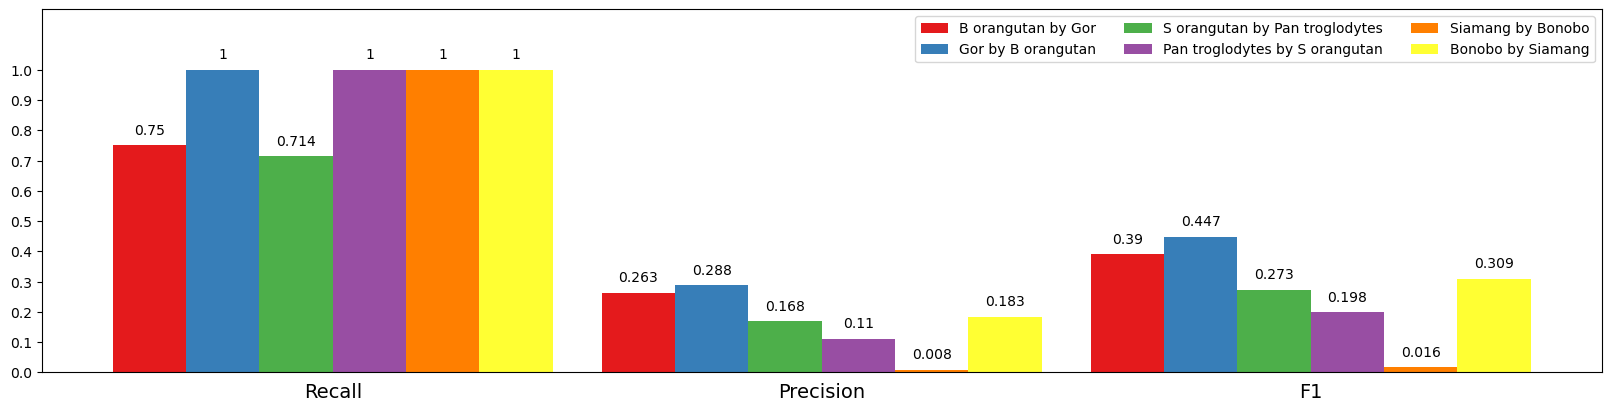

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(16, 4), layout='constrained')

ax.tick_params(axis='x', labelsize=14, bottom=False, top=False)

color_by_label = {'B orangutan by Gor': '#e41a1c', 'Gor by B orangutan': "#377eb8", 'S orangutan by Pan troglodytes': '#4daf4a', 'Pan troglodytes by S orangutan': '#984ea3', 'Siamang by Bonobo': '#ff7f00', 'Bonobo by Siamang': '#ffff33'}
width = 0.15  # the width of the bars
multiplier = 0

for label, metrics in trans_results.items():
    recall = round(metrics['recall'],3)
    precision = round(metrics['precision'],3)
    f1 = round(metrics['f1_score'],3)

    offset = width * multiplier
    rects = ax.bar(np.arange(3) + offset, [recall, precision, f1], width, label=label, color=color_by_label[label])
    ax.bar_label(rects, padding=6)
    ax.set_xticks(np.arange(3) + width*2.5, ['Recall', 'Precision', 'F1'])
    ax.set_yticks(np.arange(11)/10, np.arange(11)/10)

    ax.legend(loc='upper right', ncols=3)
    ax.set_ylim(0, 1.2)

    multiplier += 1

plt.savefig('transfer_lr.pdf')
plt.show()

In [67]:
 mono_results['pipeline']

{'B orangutan': {'precision': np.float64(0.2413793103448276),
  'recall': np.float64(0.625),
  'f1_score': np.float64(0.34825870646766166)},
 'Gor': {'precision': np.float64(0.2822085889570552),
  'recall': np.float64(1.0),
  'f1_score': np.float64(0.44019138755980863)},
 'S orangutan': {'precision': np.float64(0.19014084507042253),
  'recall': np.float64(0.9285714285714286),
  'f1_score': np.float64(0.31564748201438847)},
 'Pan troglodytes': {'precision': np.float64(0.130686517783292),
  'recall': np.float64(1.0),
  'f1_score': np.float64(0.23116313094367227)},
 'Siamang': {'precision': np.float64(0.007756563245823389),
  'recall': np.float64(1.0),
  'f1_score': np.float64(0.015393724097098873)},
 'Bonobo': {'precision': np.float64(0.18314424635332252),
  'recall': np.float64(1.0),
  'f1_score': np.float64(0.30958904109589036)}}

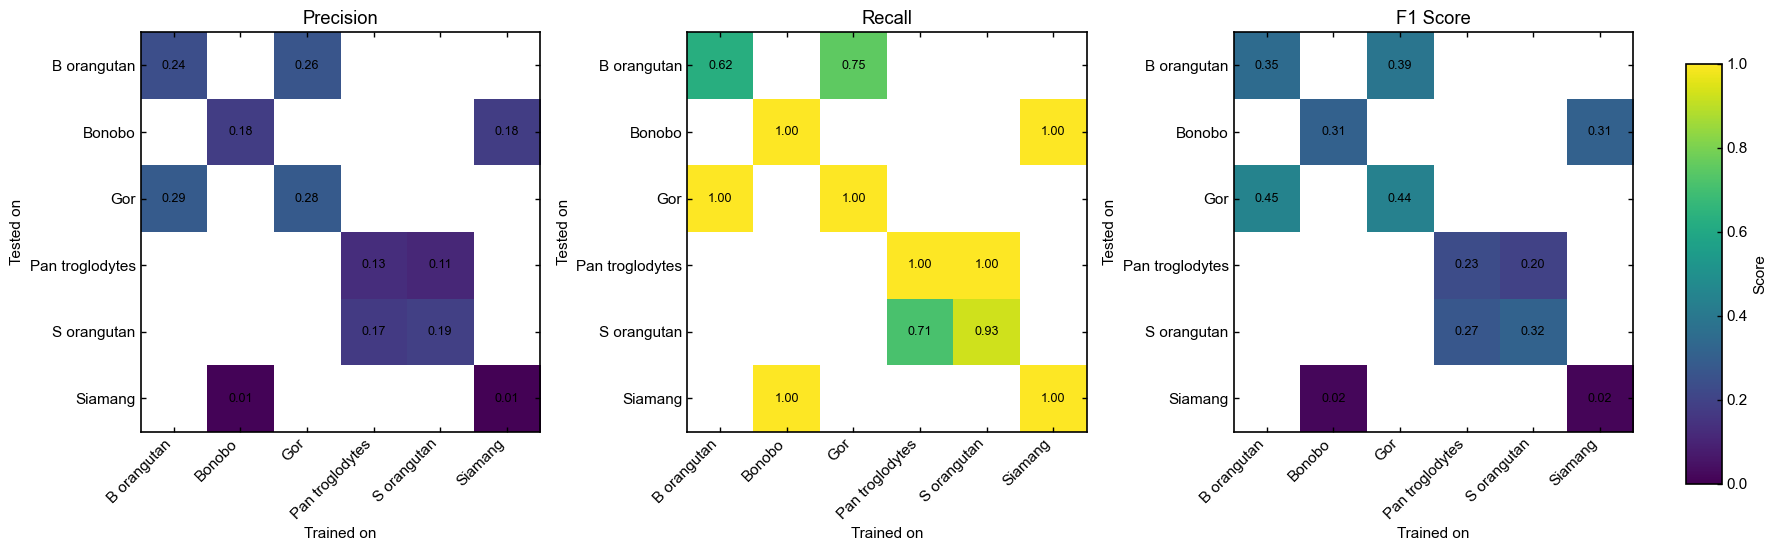

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Extract species ----
species = sorted(list(set(
    [label.split(' by ')[0] for label in trans_results.keys()] +
    [label.split(' by ')[1] for label in trans_results.keys()]
)))

n = len(species)

# Mapping species → index
idx = {sp: i for i, sp in enumerate(species)}

# ---- Initialize matrices ----
precision_mat = np.full((n, n), np.nan)
recall_mat = np.full((n, n), np.nan)
f1_mat = np.full((n, n), np.nan)

# ---- Fill matrices ----
for label, metrics in trans_results.items():
    test_sp, train_sp = label.split(' by ')
    
    i = idx[test_sp]   # row (tested on)
    j = idx[train_sp]  # column (trained on)
    
    precision_mat[i, j] = metrics['precision']
    recall_mat[i, j] = metrics['recall']
    f1_mat[i, j] = metrics['f1_score']

for label, metrics in mono_results['pipeline'].items():
    i = idx[label]
    
    precision_mat[i, i] = metrics['precision']
    recall_mat[i, i] = metrics['recall']
    f1_mat[i, i] = metrics['f1_score']

# ---- Plotting function ----
def plot_heatmap(ax, matrix, title):
    im = ax.imshow(matrix, vmin=0, vmax=1)

    # ticks
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(species, rotation=45, ha='right')
    ax.set_yticklabels(species)

    ax.set_xlabel("Trained on")
    ax.set_ylabel("Tested on")
    ax.set_title(title)

    # annotate values
    for i in range(n):
        for j in range(n):
            val = matrix[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}",
                        ha="center", va="center", fontsize=9)

    return im

# ---- Create figure ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im1 = plot_heatmap(axes[0], precision_mat, "Precision")
im2 = plot_heatmap(axes[1], recall_mat, "Recall")
im3 = plot_heatmap(axes[2], f1_mat, "F1 Score")

plt.tight_layout(rect=[0, 0, 0.92, 1])
# ---- Dedicated colorbar axis ----
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im3, cax=cbar_ax)
cbar.set_label("Score")
#plt.savefig("transfer_learning_heatmaps.pdf", dpi=300)
plt.show()

### Train on several and inference on one

In [4]:
comb_results = {}

for label, result_path in zip(['Pan_trog', 'Pan_trog_Gor', 'Pan_trog_Gor_B_orangutan', 'Pan_trog_Gor_B_orangutan_Siamang', 'Pan_trog_Gor_B_orangutan_Siamang_Bonobo', 'Pan_trog_Gor_B_orangutan_Siamang_Bonobo_S_orangutan'],

['S_orangutan_Chm_by_Pan_trog_detected_breakpoints.csv',
 'S_orangutan_trained_on_Pan_trog_Gor_detected_breakpoints.csv',
 'S_orangutan_trained_on_Pan_trog_Gor_B_orangutan_detected_breakpoints.csv',
 'S_orangutan_trained_on_Pan_trog_Gor_B_orangutan_Siamang_detected_breakpoints.csv',
 'S_orangutan_trained_on_Pan_trog_Gor_B_orangutan_Siamang_Bonobo_detected_breakpoints.csv',
 'S_orangutan_trained_on_Pan_trog_Gor_B_orangutan_Siamang_Bonobo_S_orangutan_detected_breakpoints.csv',
 ]
):
    results = pd.read_csv(f"{local_path}logs/pipeline_results/transfer_learning/combined_training/{result_path}")
    results = results[np.abs(results['x'] - results['y']) > 5*1000000]
    results.reset_index(inplace=True)
    result_res = 1
    image_size = 48
    hited_results = np.zeros(results.shape[0])

    answers_path = 'filtered_S_orangutan_Chm_SVs'
    answers = pd.read_csv(f"{local_path}data/apes/answers/{answers_path}.csv")
    answers = answers[np.abs(answers['start'] - answers['end']) > 5*1000000]
    answers.reset_index(inplace=True)
    hited_answers = np.zeros(answers.shape[0]*2)
    for i, ans in answers.iterrows():
        chr_res = results[results['chr']==ans['chr']]
        for i_x, res in chr_res.iterrows():
            if abs(res['x']-ans['end']) <=48*50000 or abs(res['y']-ans['end']) <=48*50000:
                hited_answers[i] = 1
                hited_results[i_x]=1
            if abs(res['y']-ans['start']) <=48*50000 or abs(res['x']-ans['start']) <=48*50000:
                hited_answers[i+answers.shape[0]] = 1
                hited_results[i_x]=1

    precision = sum(hited_results)/len(hited_results)
    recall = sum(hited_answers)/(len(hited_answers))
    f1_score = (2 * precision * recall)/(precision+recall)
    print(f'\n=============={label}==========================')
    print(f'TP: {sum(hited_results)}')
    print(f'Total bp repotred count: {len(hited_results)}')
    print(f'Precision: {precision}')
    print(f'Found {sum(hited_answers)} from {len(hited_answers)} breakpoints')
    print(f'Recall: {recall}')
    print(f'F1 Score: {f1_score}')
    print('===================================================\n')

    comb_results[label] = {
        'precision':precision,
        'recall':recall,
        'f1_score':f1_score
    }


==============Pan_trog==========================
TP: 47.0
Total bp repotred count: 279
Precision: 0.16845878136200718
Found 10.0 from 14 breakpoints
Recall: 0.7142857142857143
F1 Score: 0.27262180974477956


==============Pan_trog_Gor==========================
TP: 91.0
Total bp repotred count: 485
Precision: 0.18762886597938144
Found 14.0 from 14 breakpoints
Recall: 1.0
F1 Score: 0.3159722222222222


==============Pan_trog_Gor_B_orangutan==========================
TP: 88.0
Total bp repotred count: 449
Precision: 0.19599109131403117
Found 13.0 from 14 breakpoints
Recall: 0.9285714285714286
F1 Score: 0.32366671382090817


==============Pan_trog_Gor_B_orangutan_Siamang==========================
TP: 91.0
Total bp repotred count: 440
Precision: 0.20681818181818182
Found 13.0 from 14 breakpoints
Recall: 0.9285714285714286
F1 Score: 0.3382899628252788


==============Pan_trog_Gor_B_orangutan_Siamang_Bonobo==========================
TP: 90.0
Total bp repotred count: 442
Precision: 0.203619909

0.273
0.316
0.324
0.338
0.334
0.333


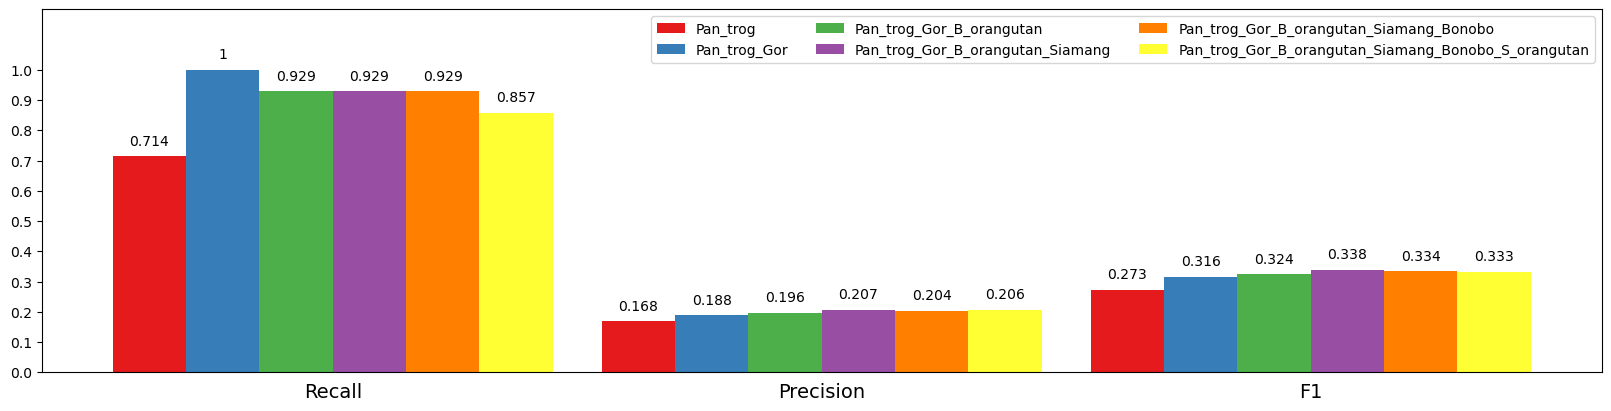

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(16, 4), layout='constrained')

ax.tick_params(axis='x', labelsize=14, bottom=False, top=False)

color_by_label = {'Pan_trog': '#e41a1c', 'Pan_trog_Gor': "#377eb8", 'Pan_trog_Gor_B_orangutan': '#4daf4a', 'Pan_trog_Gor_B_orangutan_Siamang': '#984ea3', 'Pan_trog_Gor_B_orangutan_Siamang_Bonobo': '#ff7f00', 'Pan_trog_Gor_B_orangutan_Siamang_Bonobo_S_orangutan': '#ffff33'}
width = 0.15  # the width of the bars
multiplier = 0

for label, metrics in comb_results.items():
    recall = round(metrics['recall'],3)
    precision = round(metrics['precision'],3)
    f1 = round(metrics['f1_score'],3)

    offset = width * multiplier
    rects = ax.bar(np.arange(3) + offset, [recall, precision, f1], width, label=label, color=color_by_label[label])
    ax.bar_label(rects, padding=6)
    ax.set_xticks(np.arange(3) + width*2.5, ['Recall', 'Precision', 'F1'])
    ax.set_yticks(np.arange(11)/10, np.arange(11)/10)

    ax.legend(loc='upper right', ncols=3)
    ax.set_ylim(0, 1.2)

    multiplier += 1
    print(f1)

plt.savefig('comb_train.pdf')
plt.show()

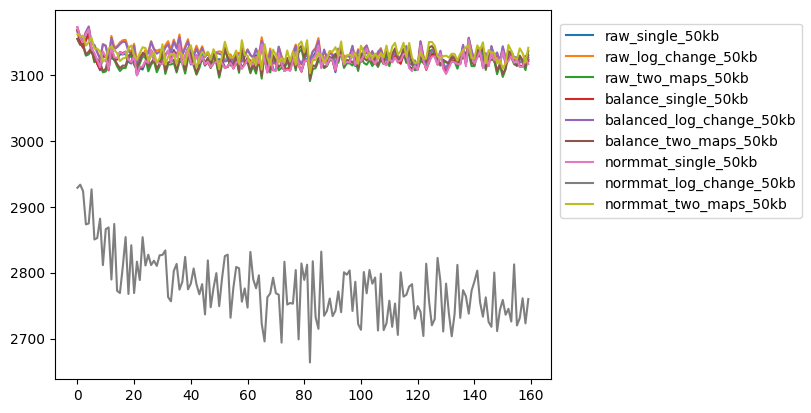

In [32]:
table_dict = {}
table_dict['Label'] = []
table_dict['Accuracy'] = []
table_dict['Recall'] = []
table_dict['Precision'] = []
table_dict['F1'] = []
losses = {}
for label, path in zip(('raw_single_15kb', 
                'raw_single_25kb', 
                'raw_single_50kb',
                'raw_log_change_15kb',
                'raw_log_change_25kb',
                'raw_log_change_50kb',
                'raw_two_maps_15kb',
                'raw_two_maps_25kb',
                'raw_two_maps_50kb',
                'balance_single_15kb', 
                'balance_single_25kb', 
                'balance_single_50kb',
                'balanced_log_change_15kb',
                'balanced_log_change_25kb',
                'balanced_log_change_50kb',
                'balance_two_maps_15kb',
                'balance_two_maps_25kb',
                'balance_two_maps_50kb',
                'normmat_single_15kb', 
                'normmat_single_25kb', 
                'normmat_single_50kb',
                'normmat_log_change_15kb',
                'normmat_log_change_25kb',
                'normmat_log_change_50kb',
                'normmat_two_maps_15kb',
                'normmat_two_maps_25kb',
                'normmat_two_maps_50kb'),
                           (f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_single_15kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_single_25kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_single_50kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_log_change_15kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_log_change_25kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_log_change_50kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_two_maps_15kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_two_maps_25kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_two_maps_50kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_balance_single_15kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_balance_single_25kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_balance_single_50kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_balanced_log_change_15kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_balanced_log_change_25kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_balanced_log_change_50kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_balance_two_maps_15kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_balance_two_maps_25kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_balance_two_maps_50kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_normmat_single_15kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_normmat_single_25kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_normmat_single_50kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_normmat_log_change_15kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_normmat_log_change_25kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_normmat_log_change_50kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_normmat_two_maps_15kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_normmat_two_maps_25kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_normmat_two_maps_50kb.log')):
    with open(path) as file:
        counter = 0
        tp = []
        tn = []
        fp = []
        fn = []
        loss = []
        if not '50kb' in label:
            continue
        for line in file:
            if counter == 6:
                tp.append(int(line.strip().removeprefix('tp ')))
                counter-=1
                continue
            if counter == 5:
                tn.append(int(line.strip().removeprefix('tn ')))
                counter-=1
                continue
            if counter == 4:
                fp.append(int(line.strip().removeprefix('fp ')))
                counter-=1
                continue
            if counter == 3:
                fn.append(int(line.strip().removeprefix('fn ')))
                counter-=1
                continue
            if counter == 2:
                counter-=1
                continue
            if counter == 1:
                loss.append(float(line.split(', ')[0].strip().removeprefix('test loss: ')))
                counter-=1
                continue
            if 'For test metrics are:' in line:
                counter = 6
    tp = tp[-1]
    tn = tn[-1]
    fp = fp[-1]
    fn = fn[-1]
    acc = round((tp+tn)/(tp+tn+fp+fn), 2)
    recall = round(tp/(tp+fn), 2)
    precision = round(tp/(tp+fp), 2)
    f1 = round((2*(tp/(tp+fp))*(tp/(tp+fn)))/((tp/(tp+fp))+(tp/(tp+fn))), 2)

    table_dict['Label'].append(label)
    table_dict['Accuracy'].append(acc)
    table_dict['Recall'].append(recall)
    table_dict['Precision'].append(precision)
    table_dict['F1'].append(f1)

    losses[label] = loss

table = pd.DataFrame(table_dict)
table.to_excel(f'{local_path}logs/december_logs/stats_test.xlsx', index=False)

fig = plt.figure()
ax = plt.subplot(111)
for label, loss in losses.items():
    ax.plot(loss, label=label)
ax.legend(loc='center right', bbox_to_anchor=(1.52, 0.7))


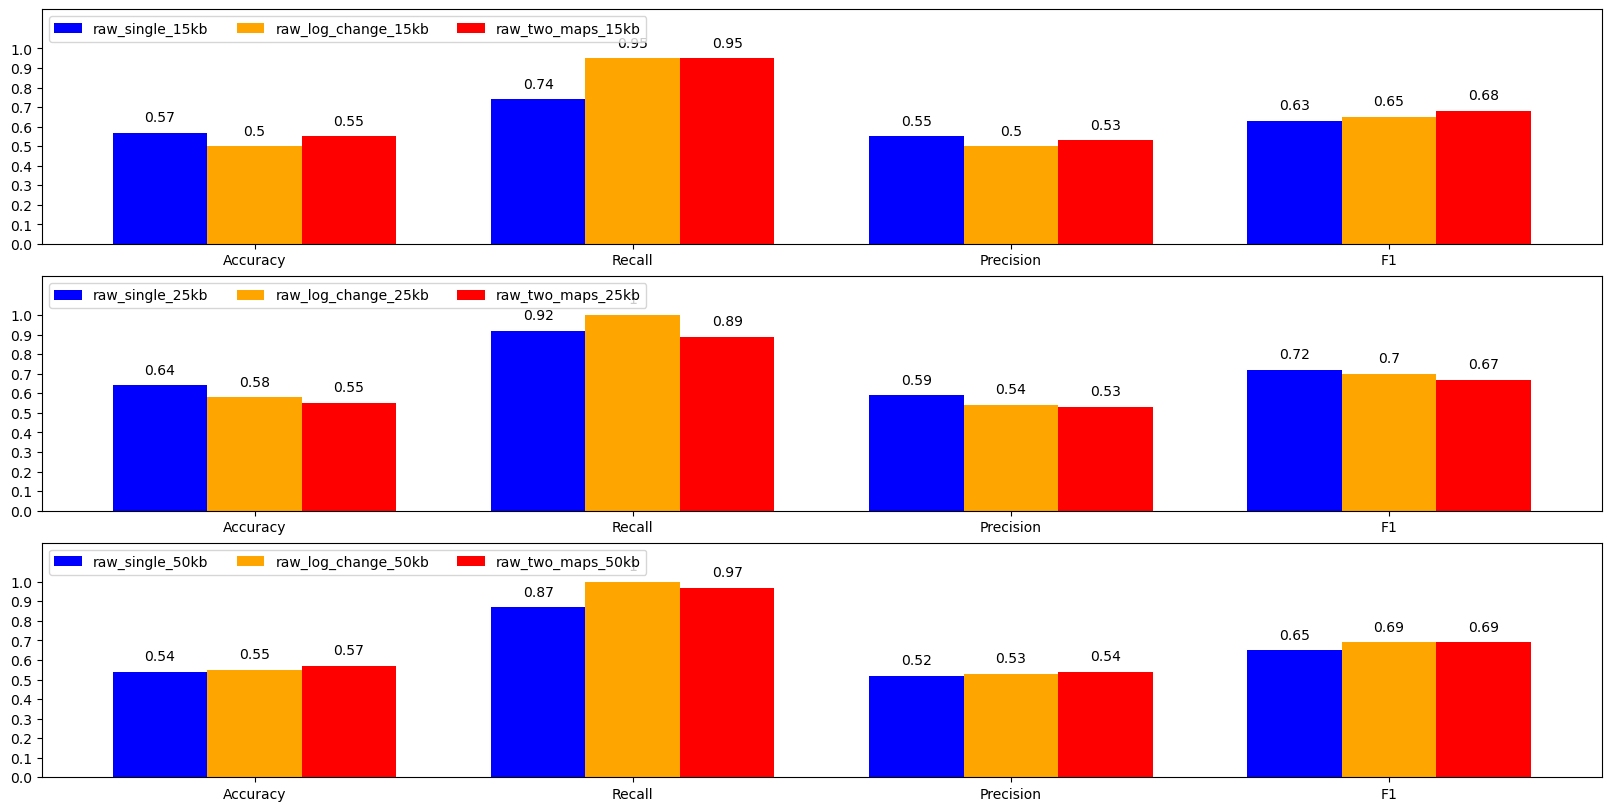

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(16, 8), layout='constrained')

width = 0.25  # the width of the bars
multiplier_10kb = 0
multiplier_25kb = 0
multiplier_50kb = 0

for log_label, path, color in zip(( 'raw_single_15kb', 
                                    'raw_single_25kb', 
                                    'raw_single_50kb',
                                    'raw_log_change_15kb',
                                    'raw_log_change_25kb',
                                    'raw_log_change_50kb',
                                    'raw_two_maps_15kb',
                                    'raw_two_maps_25kb',
                                    'raw_two_maps_50kb'),
                           (f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_single_15kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_single_25kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_single_50kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_log_change_15kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_log_change_25kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_log_change_50kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_two_maps_15kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_two_maps_25kb.log',
                            f'{local_path}logs/december_logs/train_test_logs/chm_gor_train_val_gor_raw_two_maps_50kb.log'),
                            ('blue', 'blue', 'blue',
                             'orange', 'orange', 'orange',
                             'red', 'red', 'red')):

    if '15kb' in log_label:
        m = multiplier_10kb
        ax = axs[0] 
    if '25kb' in log_label:
        m = multiplier_25kb
        ax = axs[1] 
    if '50kb' in log_label:
        m = multiplier_50kb
        ax = axs[2]
    with open(path) as file:
        counter = 0
        tp = []
        tn = []
        fp = []
        fn = []
        for line in file:
            if counter == 4:
                tp.append(int(line.strip().removeprefix('tp ')))
                counter-=1
                continue
            if counter == 3:
                tn.append(int(line.strip().removeprefix('tn ')))
                counter-=1
                continue
            if counter == 2:
                fp.append(int(line.strip().removeprefix('fp ')))
                counter-=1
                continue
            if counter == 1:
                fn.append(int(line.strip().removeprefix('fn ')))
                counter-=1
                continue
            if 'For validate metrics are:' in line:
                counter = 4
    tp = tp[-1]
    tn = tn[-1]
    fp = fp[-1]
    fn = fn[-1]
    acc = round((tp+tn)/(tp+tn+fp+fn), 2)
    recall = round(tp/(tp+fn), 2)
    precision = round(tp/(tp+fp), 2)
    f1 = round((2*(tp/(tp+fp))*(tp/(tp+fn)))/((tp/(tp+fp))+(tp/(tp+fn))), 2)
    
    offset = width * m
    rects = ax.bar(np.arange(4) + offset, [acc, recall, precision, f1], width, label=log_label, color=color)
    ax.bar_label(rects, padding=6)
    #plt.bar(['Accuracy', 'Recall', 'Precision', 'F1'], [acc, recall, precision, f1], label=log_label)
    ax.set_xticks(np.arange(4) + width, ['Accuracy', 'Recall', 'Precision', 'F1'])
    ax.set_yticks(np.arange(11)/10, np.arange(11)/10)

    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1.2)

    if '15kb' in log_label:
        multiplier_10kb += 1
    if '25kb' in log_label:
        multiplier_25kb += 1 
    if '50kb' in log_label:
        multiplier_50kb += 1 
plt.show()

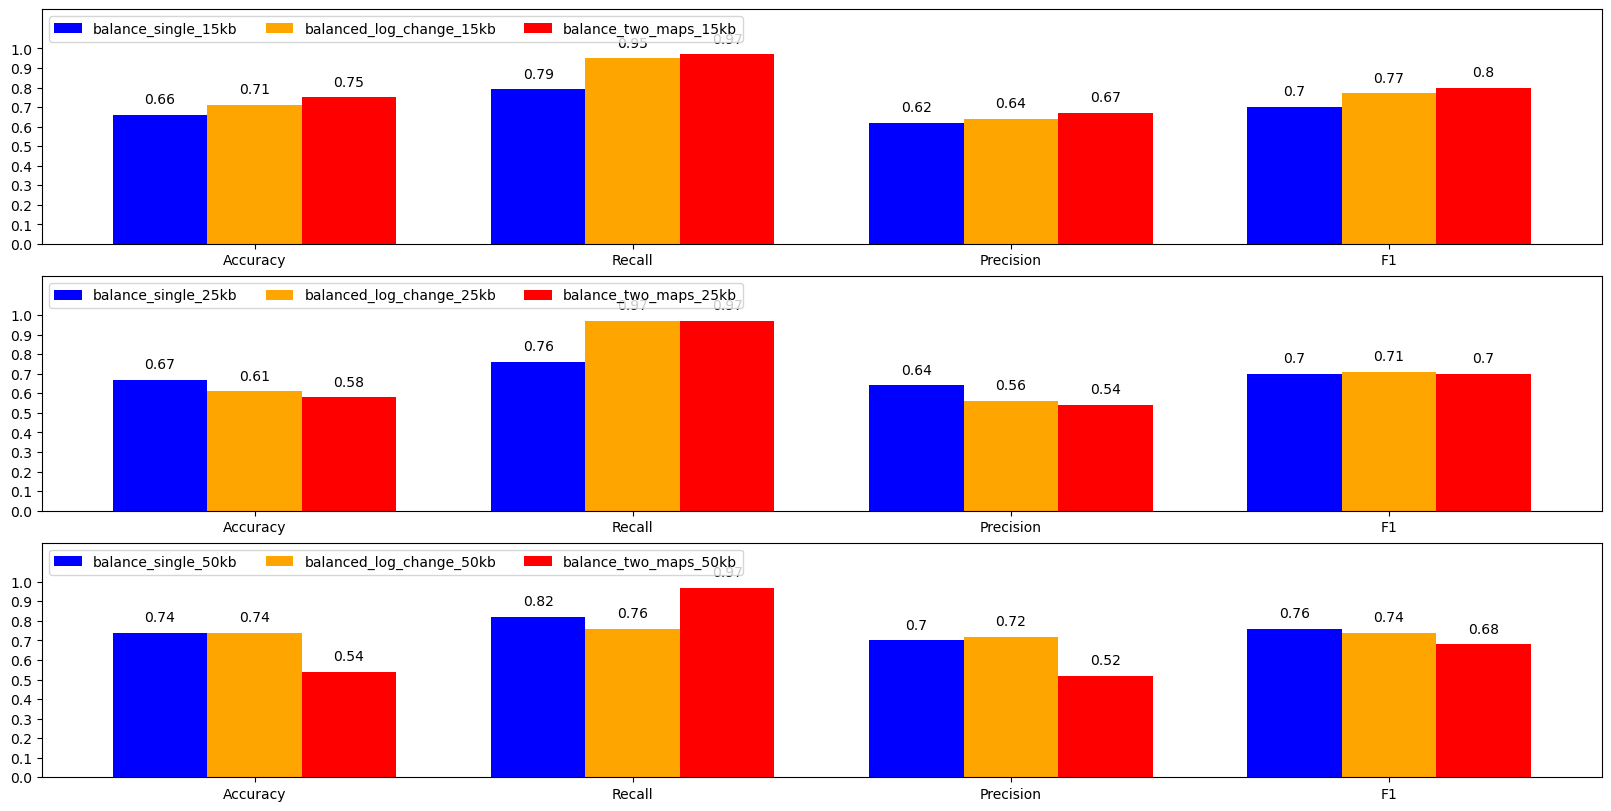

In [3]:
fig, axs = plt.subplots(3, 1, figsize=(16, 8), layout='constrained')

width = 0.25  # the width of the bars
multiplier_10kb = 0
multiplier_25kb = 0
multiplier_50kb = 0

for log_label, path, color in zip(( 'balance_single_15kb', 
                                    'balance_single_25kb', 
                                    'balance_single_50kb',
                                    'balanced_log_change_15kb',
                                    'balanced_log_change_25kb',
                                    'balanced_log_change_50kb',
                                    'balance_two_maps_15kb',
                                    'balance_two_maps_25kb',
                                    'balance_two_maps_50kb'),
                           ('train_test_logs/chm_gor_train_val_gor_balance_single_15kb.log',
                            'train_test_logs/chm_gor_train_val_gor_balance_single_25kb.log',
                            'train_test_logs/chm_gor_train_val_gor_balance_single_50kb.log',
                            'train_test_logs/chm_gor_train_val_gor_balanced_log_change_15kb.log',
                            'train_test_logs/chm_gor_train_val_gor_balanced_log_change_25kb.log',
                            'train_test_logs/chm_gor_train_val_gor_balanced_log_change_50kb.log',
                            'train_test_logs/chm_gor_train_val_gor_balance_two_maps_15kb.log',
                            'train_test_logs/chm_gor_train_val_gor_balance_two_maps_25kb.log',
                            'train_test_logs/chm_gor_train_val_gor_balance_two_maps_50kb.log'),
                            ('blue', 'blue', 'blue',
                             'orange', 'orange', 'orange',
                             'red', 'red', 'red')):

    if '15kb' in log_label:
        m = multiplier_10kb
        ax = axs[0] 
    if '25kb' in log_label:
        m = multiplier_25kb
        ax = axs[1] 
    if '50kb' in log_label:
        m = multiplier_50kb
        ax = axs[2]
    with open(path) as file:
        counter = 0
        tp = []
        tn = []
        fp = []
        fn = []
        for line in file:
            if counter == 4:
                tp.append(int(line.strip().removeprefix('tp ')))
                counter-=1
                continue
            if counter == 3:
                tn.append(int(line.strip().removeprefix('tn ')))
                counter-=1
                continue
            if counter == 2:
                fp.append(int(line.strip().removeprefix('fp ')))
                counter-=1
                continue
            if counter == 1:
                fn.append(int(line.strip().removeprefix('fn ')))
                counter-=1
                continue
            if 'For validate metrics are:' in line:
                counter = 4
    tp = tp[-1]
    tn = tn[-1]
    fp = fp[-1]
    fn = fn[-1]
    acc = round((tp+tn)/(tp+tn+fp+fn), 2)
    recall = round(tp/(tp+fn), 2)
    precision = round(tp/(tp+fp), 2)
    f1 = round((2*(tp/(tp+fp))*(tp/(tp+fn)))/((tp/(tp+fp))+(tp/(tp+fn))), 2)
    
    offset = width * m
    rects = ax.bar(np.arange(4) + offset, [acc, recall, precision, f1], width, label=log_label, color=color)
    ax.bar_label(rects, padding=6)
    #plt.bar(['Accuracy', 'Recall', 'Precision', 'F1'], [acc, recall, precision, f1], label=log_label)
    ax.set_xticks(np.arange(4) + width, ['Accuracy', 'Recall', 'Precision', 'F1'])
    ax.set_yticks(np.arange(11)/10, np.arange(11)/10)

    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1.2)

    if '15kb' in log_label:
        multiplier_10kb += 1
    if '25kb' in log_label:
        multiplier_25kb += 1 
    if '50kb' in log_label:
        multiplier_50kb += 1 
plt.show()

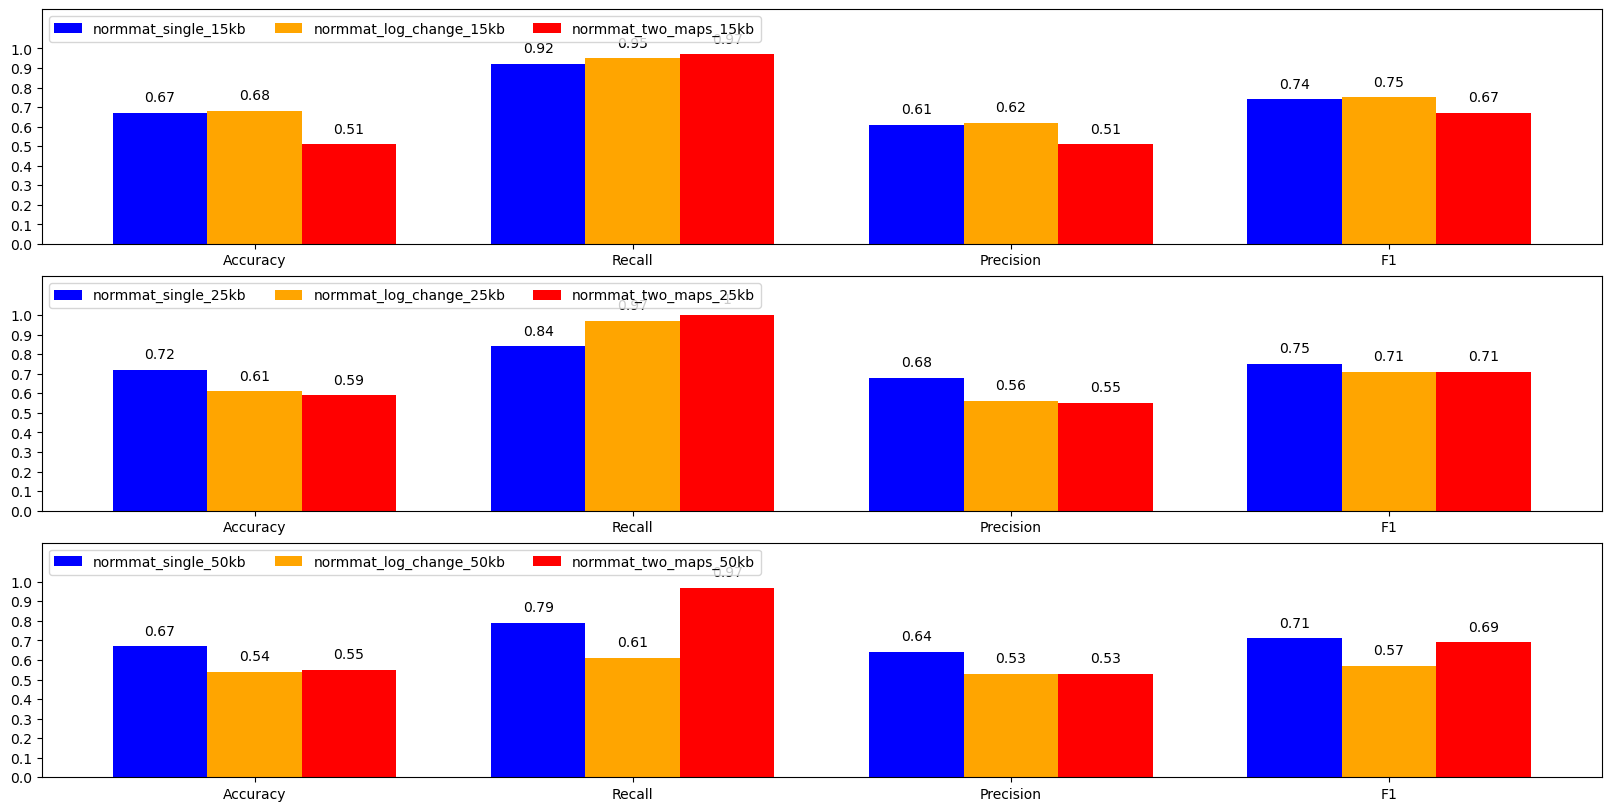

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(16, 8), layout='constrained')

width = 0.25  # the width of the bars
multiplier_10kb = 0
multiplier_25kb = 0
multiplier_50kb = 0

for log_label, path, color in zip(( 'normmat_single_15kb', 
                                    'normmat_single_25kb', 
                                    'normmat_single_50kb',
                                    'normmat_log_change_15kb',
                                    'normmat_log_change_25kb',
                                    'normmat_log_change_50kb',
                                    'normmat_two_maps_15kb',
                                    'normmat_two_maps_25kb',
                                    'normmat_two_maps_50kb'),
                           ('train_test_logs/chm_gor_train_val_gor_normmat_single_15kb.log',
                            'train_test_logs/chm_gor_train_val_gor_normmat_single_25kb.log',
                            'train_test_logs/chm_gor_train_val_gor_normmat_single_50kb.log',
                            'train_test_logs/chm_gor_train_val_gor_normmat_log_change_15kb.log',
                            'train_test_logs/chm_gor_train_val_gor_normmat_log_change_25kb.log',
                            'train_test_logs/chm_gor_train_val_gor_normmat_log_change_50kb.log',
                            'train_test_logs/chm_gor_train_val_gor_normmat_two_maps_15kb.log',
                            'train_test_logs/chm_gor_train_val_gor_normmat_two_maps_25kb.log',
                            'train_test_logs/chm_gor_train_val_gor_normmat_two_maps_50kb.log'),
                            ('blue', 'blue', 'blue',
                             'orange', 'orange', 'orange',
                             'red', 'red', 'red')):

    if '15kb' in log_label:
        m = multiplier_10kb
        ax = axs[0] 
    if '25kb' in log_label:
        m = multiplier_25kb
        ax = axs[1] 
    if '50kb' in log_label:
        m = multiplier_50kb
        ax = axs[2]
    with open(path) as file:
        counter = 0
        tp = []
        tn = []
        fp = []
        fn = []
        for line in file:
            if counter == 4:
                tp.append(int(line.strip().removeprefix('tp ')))
                counter-=1
                continue
            if counter == 3:
                tn.append(int(line.strip().removeprefix('tn ')))
                counter-=1
                continue
            if counter == 2:
                fp.append(int(line.strip().removeprefix('fp ')))
                counter-=1
                continue
            if counter == 1:
                fn.append(int(line.strip().removeprefix('fn ')))
                counter-=1
                continue
            if 'For validate metrics are:' in line:
                counter = 4
    tp = tp[-1]
    tn = tn[-1]
    fp = fp[-1]
    fn = fn[-1]
    acc = round((tp+tn)/(tp+tn+fp+fn), 2)
    recall = round(tp/(tp+fn), 2)
    precision = round(tp/(tp+fp), 2)
    f1 = round((2*(tp/(tp+fp))*(tp/(tp+fn)))/((tp/(tp+fp))+(tp/(tp+fn))), 2)
    
    offset = width * m
    rects = ax.bar(np.arange(4) + offset, [acc, recall, precision, f1], width, label=log_label, color=color)
    ax.bar_label(rects, padding=6)
    #plt.bar(['Accuracy', 'Recall', 'Precision', 'F1'], [acc, recall, precision, f1], label=log_label)
    ax.set_xticks(np.arange(4) + width, ['Accuracy', 'Recall', 'Precision', 'F1'])
    ax.set_yticks(np.arange(11)/10, np.arange(11)/10)

    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1.2)

    if '15kb' in log_label:
        multiplier_10kb += 1
    if '25kb' in log_label:
        multiplier_25kb += 1 
    if '50kb' in log_label:
        multiplier_50kb += 1 
plt.show()

In [ ]:
max_precision = 0
for norm_type in ['raw', 'balance', 'normmat']:
    print(norm_type)
    for strategy in ['single', 'log_change', 'two_maps']:
        print(strategy)
        for res_label, result_res in zip(['15kb','25kb', '50kb'], [15000, 25000, 50000]):
            results = pd.read_csv(f"{local_path}logs/december_logs/validate_logs/{norm_type}_{strategy}_gor_{res_label}.csv")
            results = results[(results.label >= 0.7)]
            answers = pd.read_csv(f"{local_path}data/apes/Gor_Chm_SVs.csv")

            #results_by_chr = get_chromosome_coords(sorted(list(results.x)), ape_chm.chromsizes, ape_chm.chromnames, result_res)
            answers_dict = {}
            for index, row in answers.iterrows():
                if row.chr in answers_dict:
                    answers_dict[row.chr].append(answers.start)
                else:
                    answers_dict[row.chr] = [answers.start, ]
            
            all_chr = set(answers_dict.keys())
            all_chr.update(set(results.chr.to_list()))
            all_chr = list(all_chr)
            hited_segements_all = []
            answers_bp_x_hited_all = []
            ans_bp_count = 0
            for cur_chr in all_chr:
                bps = np.array(sorted(results.loc[results['chr']==cur_chr, 'x']), dtype=np.int64)
                if len(bps) == 0:
                    continue
                image_size = 48

                segments = []
                segment_start = bps[0]-image_size//2
                segment_end = bps[0]+image_size//2
                for bp in bps:
                    if bp-segment_end > image_size:
                        segments.append((segment_start, segment_end))
                        segment_start = bp-image_size//2
                    segment_end = bp+image_size//2

                answers_cur = answers[answers['chr'] == cur_chr]
                ans_bp = list(answers_cur.start//result_res)
                ans_bp.extend(list(answers_cur.end//result_res))
                ans_bp = sorted(ans_bp)
                ans_bp_count+=len(ans_bp)
                answers_bp_x_hited = np.zeros(len(ans_bp))

                hited_segements = np.zeros(len(segments))
                for i, segment in enumerate(segments):
                    for i_x, bp_x in enumerate(ans_bp):
                        if segment[0]-24<= bp_x <= segment[1]+24:
                            hited_segements[i] = 1
                            answers_bp_x_hited[i_x] += 1
                hited_segements_all.append(hited_segements)
                answers_bp_x_hited_all.append(answers_bp_x_hited)

            if len(hited_segements_all):
                hited_segements_all = np.concatenate(hited_segements_all)
            
            if len(answers_bp_x_hited_all):
                answers_bp_x_hited_all = np.concatenate(answers_bp_x_hited_all)
            
            if len(hited_segements_all) > 0:
                precision = sum(hited_segements_all)/len(hited_segements_all)
            else:
                precision = 0
            print(res_label)
            print('\n===================================================')
            print(f'Segments that have bp within: {sum(hited_segements_all)}')
            print(f'Total segments count: {len(hited_segements_all)}')
            print(f'Precision: {precision}')
            print(f'Found {sum(answers_bp_x_hited_all)} from {ans_bp_count} breakpoints')
            print('===================================================\n')

raw
single
15kb

Segments that have bp within: 1.0
Total segments count: 4
Precision: 0.25
Found 2.0 from 78 breakpoints

25kb

Segments that have bp within: 1.0
Total segments count: 4
Precision: 0.25
Found 8.0 from 54 breakpoints

50kb

Segments that have bp within: 0
Total segments count: 0
Precision: 0
Found 0 from 0 breakpoints

log_change
15kb

Segments that have bp within: 4.0
Total segments count: 43
Precision: 0.09302325581395349
Found 5.0 from 324 breakpoints

25kb

Segments that have bp within: 3.0
Total segments count: 20
Precision: 0.15
Found 4.0 from 264 breakpoints

50kb

Segments that have bp within: 11.0
Total segments count: 106
Precision: 0.10377358490566038
Found 30.0 from 336 breakpoints

two_maps
15kb

Segments that have bp within: 4.0
Total segments count: 32
Precision: 0.125
Found 9.0 from 250 breakpoints

25kb

Segments that have bp within: 7.0
Total segments count: 48
Precision: 0.14583333333333334
Found 12.0 from 272 breakpoints

50kb

Segments that have bp w

raw
single


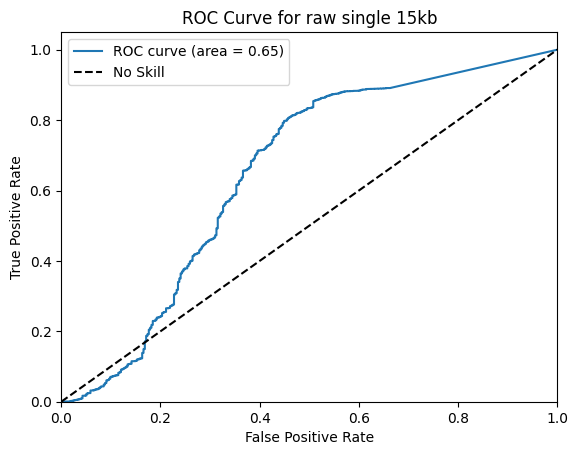

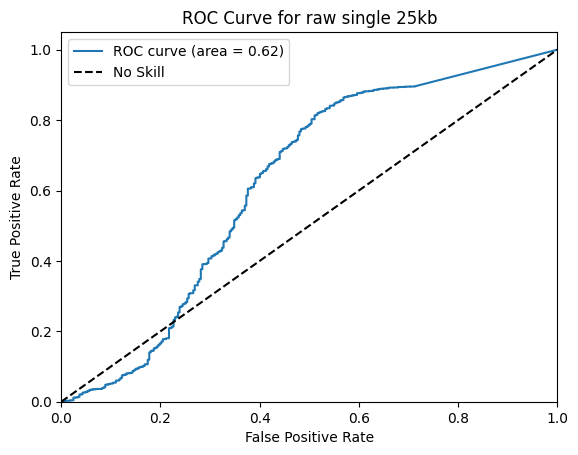

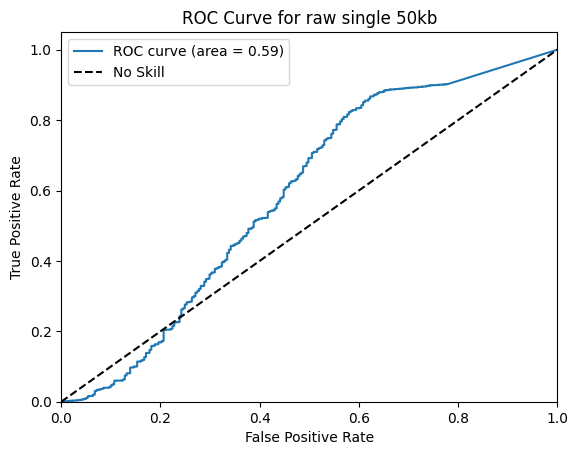

log_change


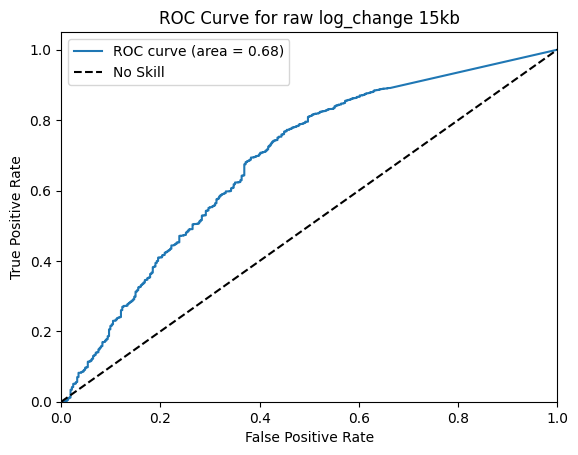

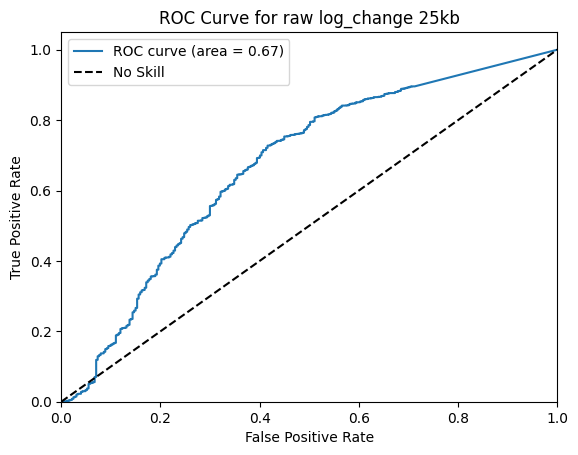

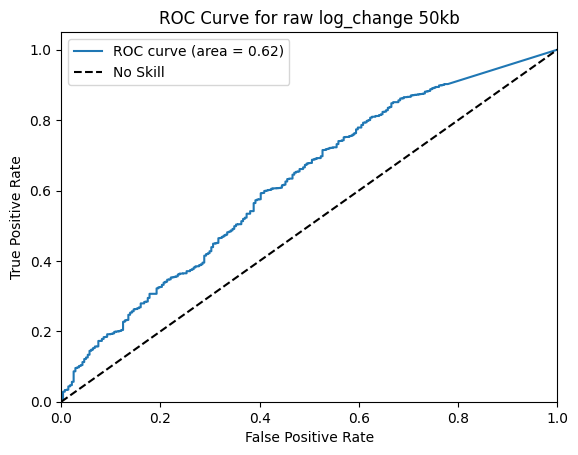

two_maps


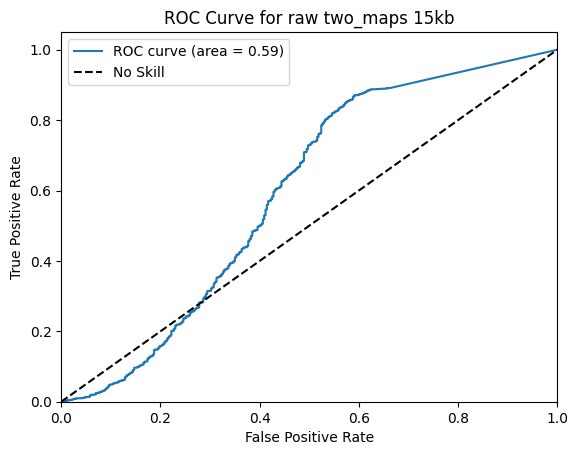

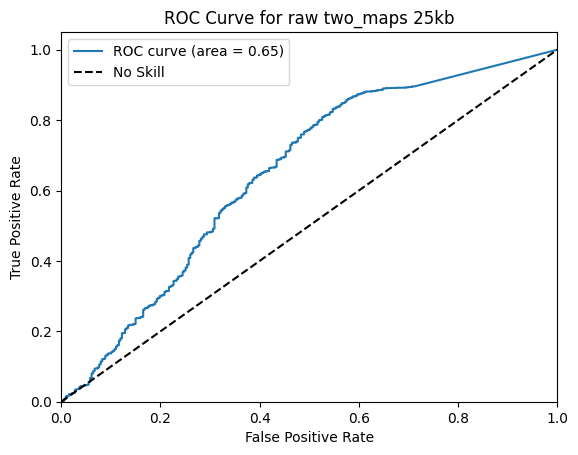

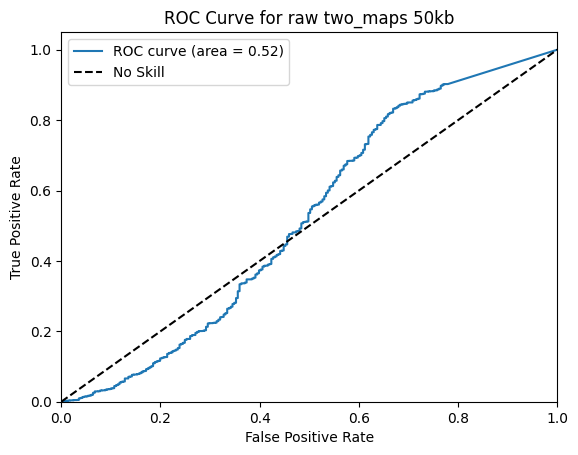

balance
single


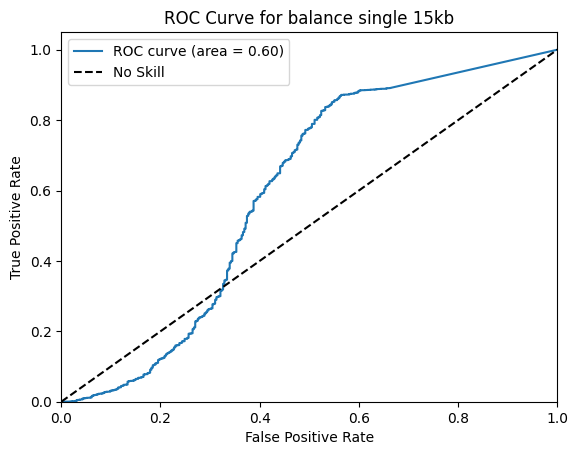

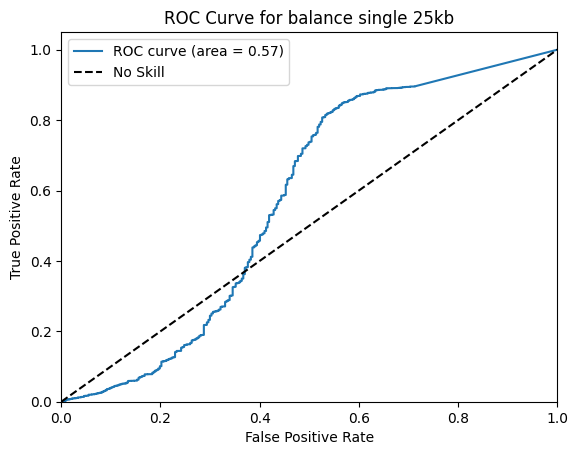

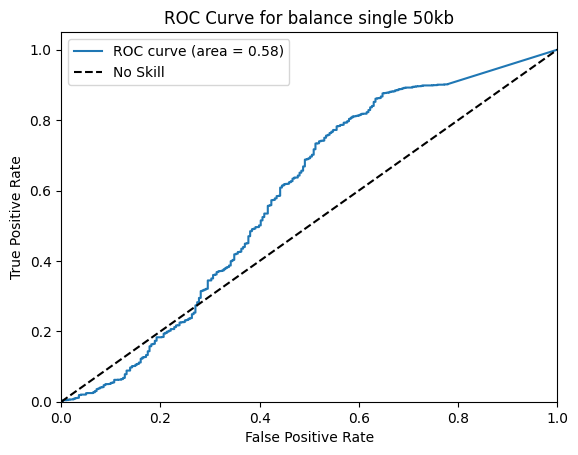

log_change


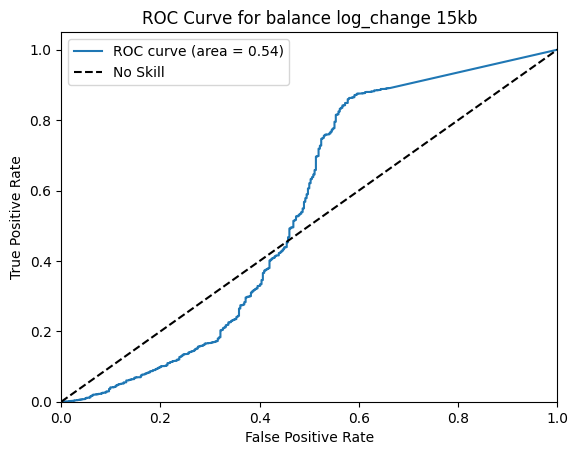

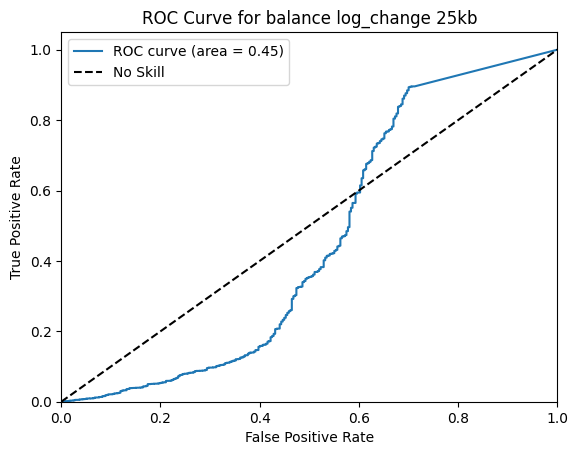

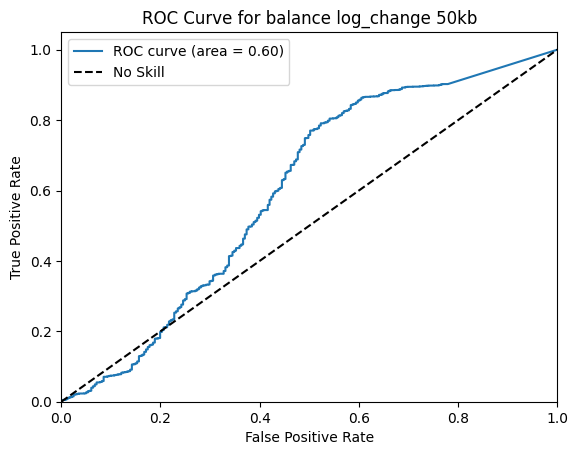

two_maps


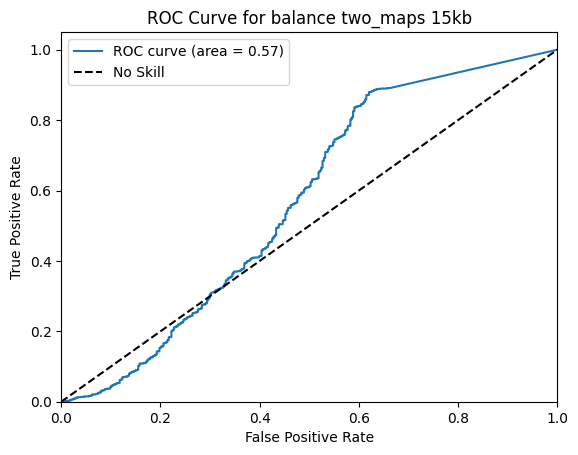

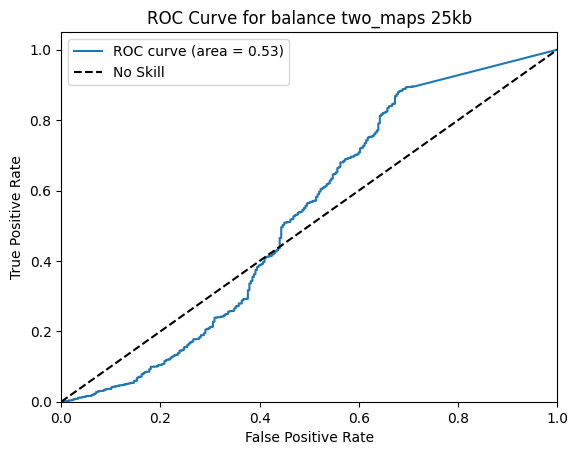

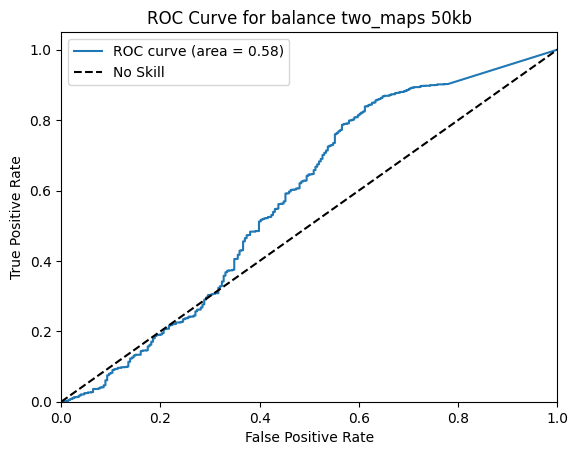

normmat
single


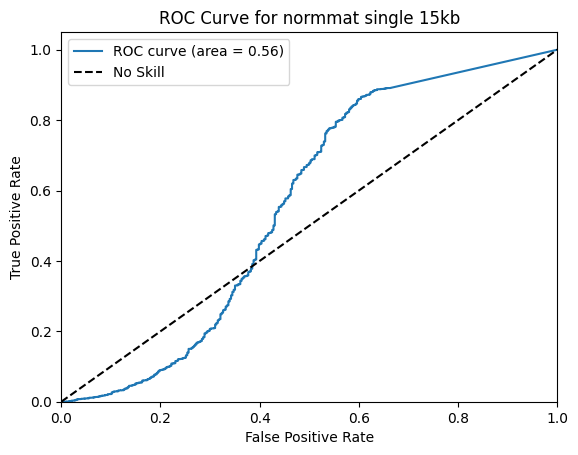

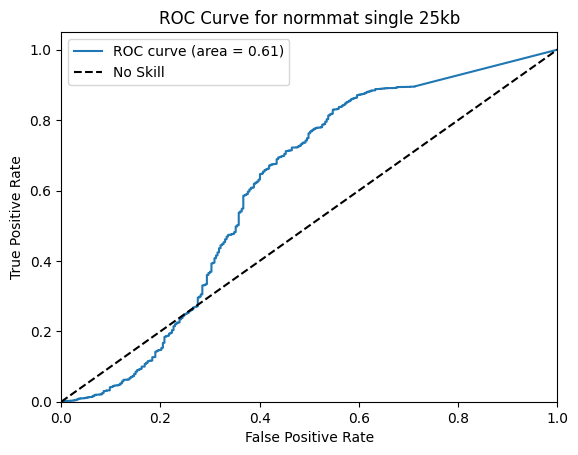

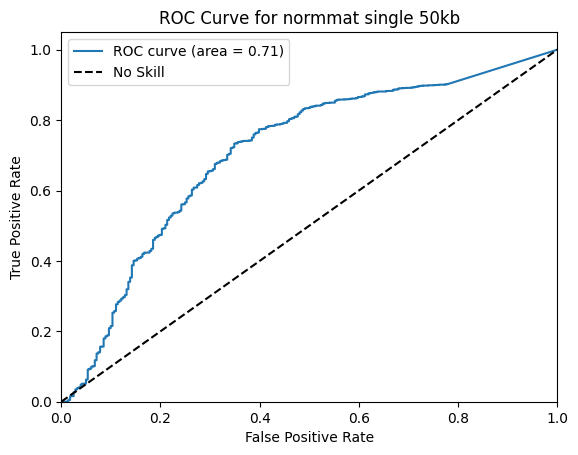

log_change


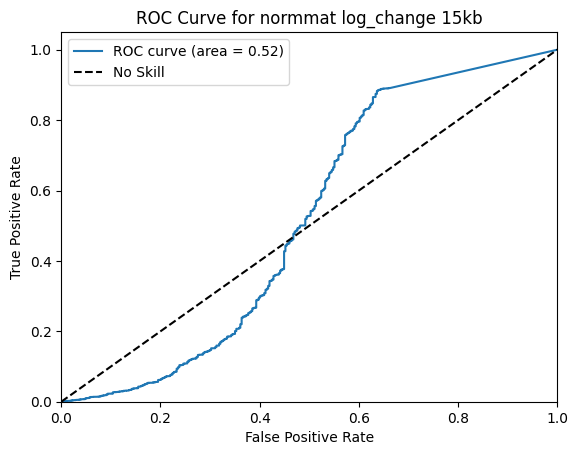

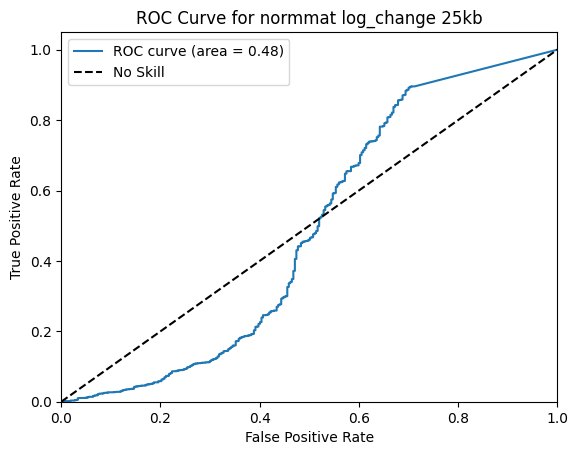

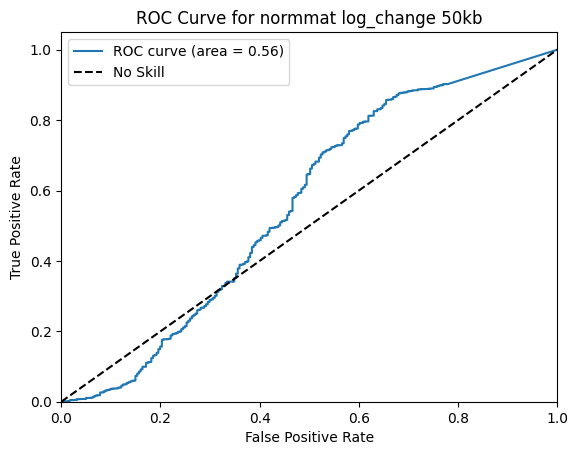

two_maps


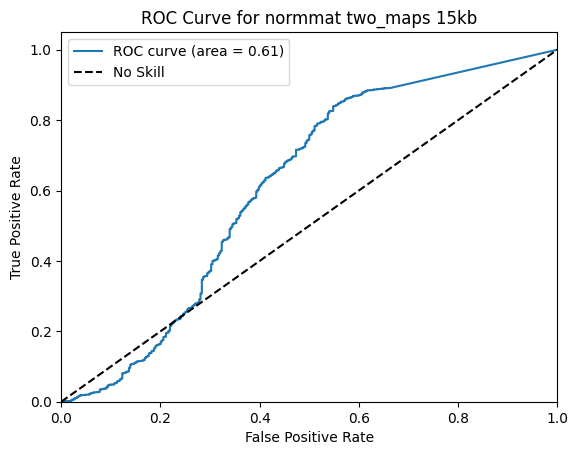

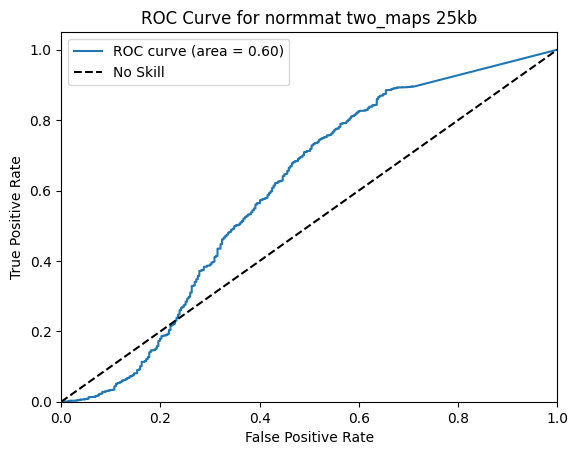

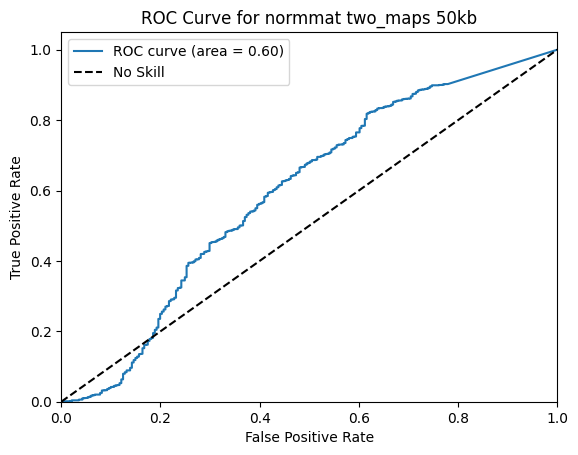

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

for norm_type in ['raw', 'balance', 'normmat']:
    print(norm_type)
    for strategy in ['single', 'log_change', 'two_maps']:
        print(strategy)
        for res_label, result_res in zip(['15kb','25kb', '50kb'], [15000, 25000, 50000]):
            results = pd.read_csv(f"{local_path}logs/december_logs/validate_logs/{norm_type}_{strategy}_gor_{res_label}.csv")
            #results = results[(results.label >= 0.7)]
            answers = pd.read_csv(f"{local_path}data/apes/Gor_Chm_SVs.csv")

            answers_dict = {}
            for index, row in answers.iterrows():
                if row.chr in answers_dict:
                    answers_dict[row.chr].append(answers.start)
                else:
                    answers_dict[row.chr] = [answers.start, ]

            all_chr = set(answers_dict.keys())
            all_chr.update(set(results.chr.to_list()))
            all_chr = list(all_chr)
            hited_bps_all = []
            labels_all = []
            answers_bp_x_hited_all = []
            ans_bp_count = 0
            for cur_chr in all_chr:
                bps = np.array(results.loc[results['chr']==cur_chr, 'x'], dtype=np.int64)
                labels = np.array(results.loc[results['chr']==cur_chr, 'label'])

                if len(bps) == 0:
                    continue
                image_size = 48

                #segments = []
                #segments_labels = []
                #segment_start = bps[0]-image_size//2
                #segment_end = bps[0]+image_size//2
                #labels_sum = labels[0]
                #labels_count = 1
                #for bp,label in zip(bps[1:], labels[1:]):
                #    if bp-segment_end > image_size:
                #        mean = labels_sum/labels_count
                #        segments_labels.append(mean)
                #        segments.append((segment_start, segment_end))
                #        segment_start = bp-image_size//2
                #        labels_sum = label
                #        labels_count = 1
                #    segment_end = bp+image_size//2
                #    labels_sum +=label
                #    labels_count+=1
                #segments_labels_all.append(segments_labels)
                answers_cur = answers[answers['chr'] == cur_chr]
                ans_bp = list(answers_cur.start//result_res)
                ans_bp.extend(list(answers_cur.end//result_res))
                ans_bp = sorted(ans_bp)
                ans_bp_count+=len(ans_bp)
                answers_bp_x_hited = np.zeros(len(ans_bp))

                hited_bps = np.ones(len(bps))
                for i, bp in enumerate(bps):
                    for i_x, bp_x in enumerate(ans_bp):
                        if bp-24<= bp_x <= bp+24:
                            hited_bps[i] = 0
                            answers_bp_x_hited[i_x] += 1
                hited_bps_all.append(hited_bps)
                labels_all.append(labels)
                answers_bp_x_hited_all.append(answers_bp_x_hited)

            if len(labels_all):
                labels_all = np.concatenate(labels_all)

            if len(hited_bps_all):
                hited_bps_all = np.concatenate(hited_bps_all)


            if len(answers_bp_x_hited_all):
                answers_bp_x_hited_all = np.concatenate(answers_bp_x_hited_all)

            fpr, tpr, thresholds = roc_curve(hited_bps_all, labels_all)
            roc_auc = auc(fpr, tpr)

            plt.figure()  
            plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
            plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC Curve for {norm_type} {strategy} {res_label}')
            plt.legend()
            plt.show()

# Number of SVs by min size threshold

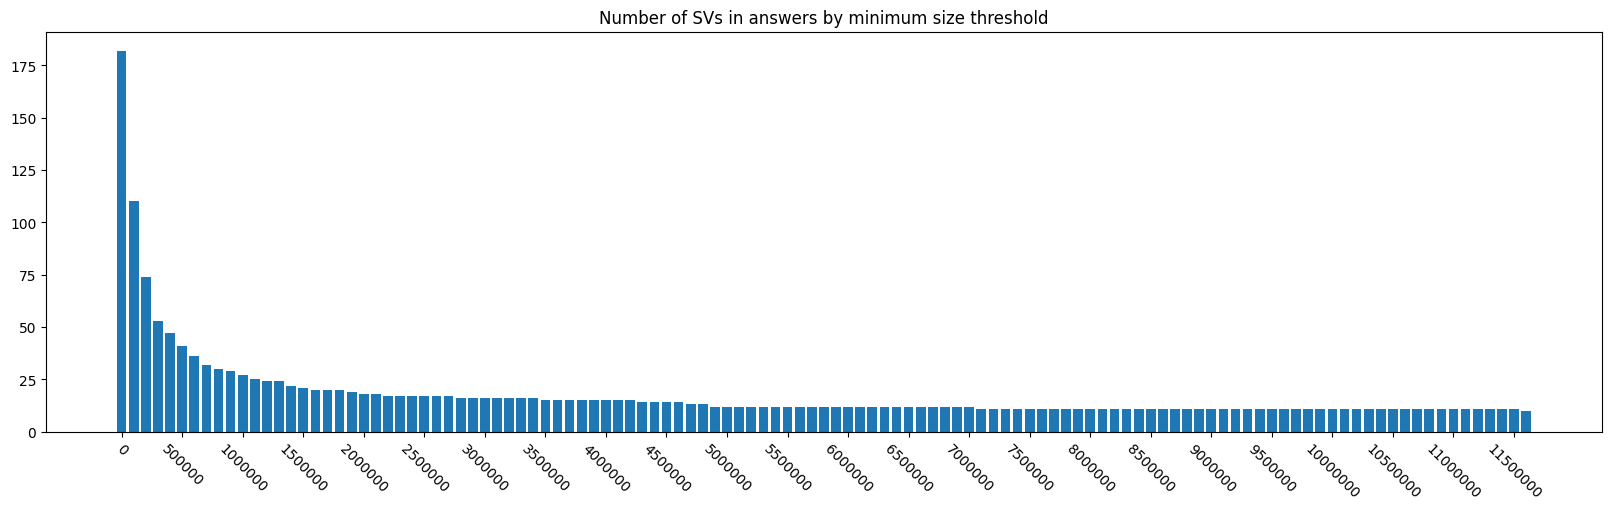

In [37]:
fig, ax = plt.subplots(figsize=(16, 5), layout='constrained')

answers = pd.read_csv(f"{local_path}data/apes/Gor_Chm_SVs.csv")

step = 100000
i=0
counts = []
sv_count = answers.shape[0]
min_sizes = []
while sv_count > 10:
    sv_count = sum(np.abs(answers['start'] - answers['end']) > i*step)
    counts.append(sv_count)
    min_sizes.append(i)
    i+=1

ax.bar(min_sizes, counts)
min_sizes_ticks = min_sizes[::5]
ax.set_xticks(min_sizes_ticks)
ax.set_xticklabels([t*step for t in min_sizes_ticks], rotation=-45)
ax.set_title('Number of SVs in answers by minimum size threshold')
plt.show()

182it [00:02, 80.22it/s]
41it [00:00, 64.53it/s]
27it [00:00, 94.38it/s]
21it [00:00, 157.11it/s]
18it [00:00, 368.94it/s]
17it [00:00, 495.73it/s]
16it [00:00, 887.41it/s]
15it [00:00, 690.16it/s]
15it [00:00, 3206.16it/s]
14it [00:00, 7018.08it/s]
12it [00:00, ?it/s]
12it [00:00, 892.07it/s]
12it [00:00, ?it/s]
12it [00:00, ?it/s]
12it [00:00, 3860.38it/s]
11it [00:00, ?it/s]
11it [00:00, 4216.92it/s]
11it [00:00, ?it/s]
11it [00:00, 645.57it/s]
11it [00:00, ?it/s]
11it [00:00, 2737.63it/s]
11it [00:00, 860.71it/s]
11it [00:00, ?it/s]
11it [00:00, 817.33it/s]
10it [00:00, 629.00it/s]


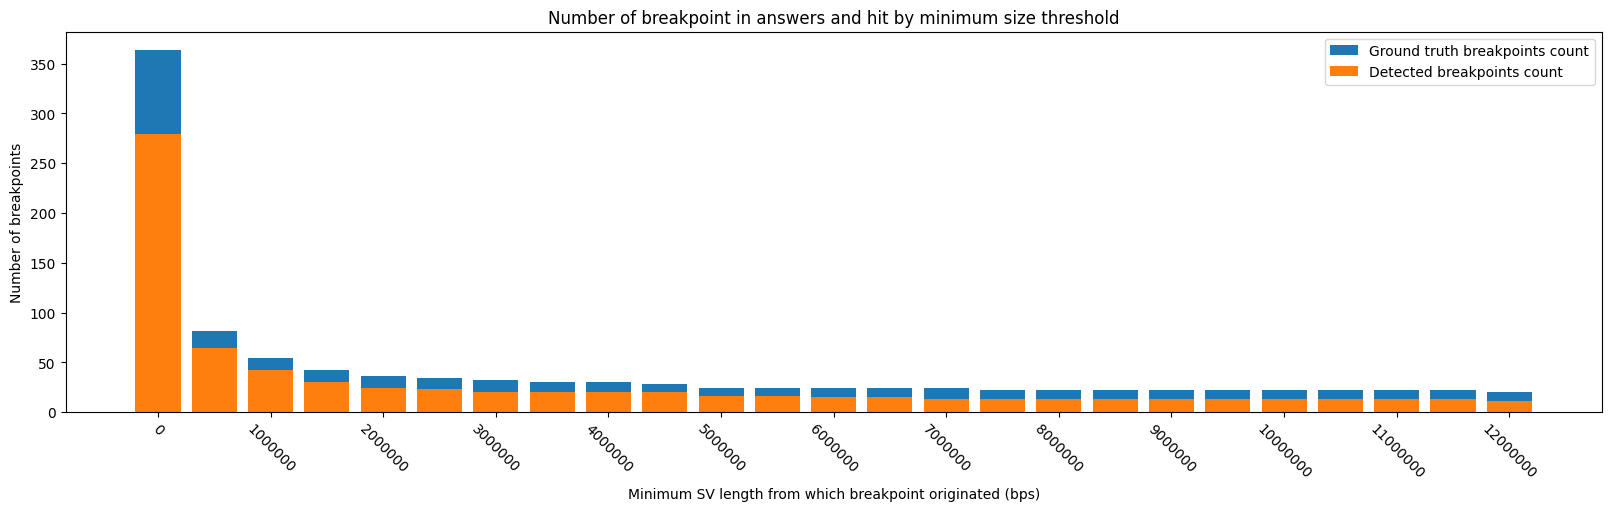

In [48]:
from tqdm import tqdm
results = pd.read_csv(f"{local_path}logs/december_logs/voting_wm_06_masked.csv")
answers = pd.read_csv(f"{local_path}data/apes/Gor_Chm_SVs.csv")


step = 500000
i=0
counts = []
tps = []
total_calls_counts = []
hited_answers_counts = []
sv_count = answers.shape[0]
min_sizes = []
while sv_count > 10:
    sv_count = sum(np.abs(answers['start'] - answers['end']) > i*step)
    counts.append(sv_count*2)
    min_sizes.append(i)

    res_i = results[np.abs(results['x'] - results['y']) > i*step].copy()
    res_i.reset_index(inplace=True)
    total_calls_counts.append(res_i.shape[0])
    result_res = 1
    image_size = 48
    hited_results = np.zeros(res_i.shape[0])
    ans_i = answers[np.abs(answers['start'] - answers['end']) > i*step].copy()
    ans_i.reset_index(inplace=True)
    hited_answers = np.zeros(ans_i.shape[0]*2)
    assert sv_count == ans_i.shape[0]

    for j, ans in tqdm(ans_i.iterrows()):
        chr_res = res_i[res_i['chr']==ans['chr']]
        for i_x, res in chr_res.iterrows():
            if abs(res['x']-ans['end']) <=48*50000 or abs(res['y']-ans['end']) <=48*50000:
                hited_answers[j] = 1
                hited_results[i_x]=1
            if abs(res['y']-ans['start']) <=48*50000 or abs(res['x']-ans['start']) <=48*50000:
                hited_answers[j+ans_i.shape[0]] = 1
                hited_results[i_x]=1
    
    tps.append(sum(hited_results))
    hited_answers_counts.append(sum(hited_answers))
    i+=1


fig, ax = plt.subplots(figsize=(16, 5), layout='constrained')
ax.bar(min_sizes, counts, label='Ground truth breakpoints count')
ax.bar(min_sizes, hited_answers_counts, label='Detected breakpoints count')
#ax.bar(min_sizes, tps, label='True positive calls count')


min_sizes_ticks = min_sizes[::2]
ax.set_xticks(min_sizes_ticks)
ax.set_xticklabels([t*step for t in min_sizes_ticks], rotation=-45)
ax.set_title('Number of breakpoint in answers and hit by minimum size threshold')
ax.set_xlabel('Minimum SV length from which breakpoint originated (bps)')
ax.set_ylabel('Number of breakpoints')

plt.legend()
plt.show()




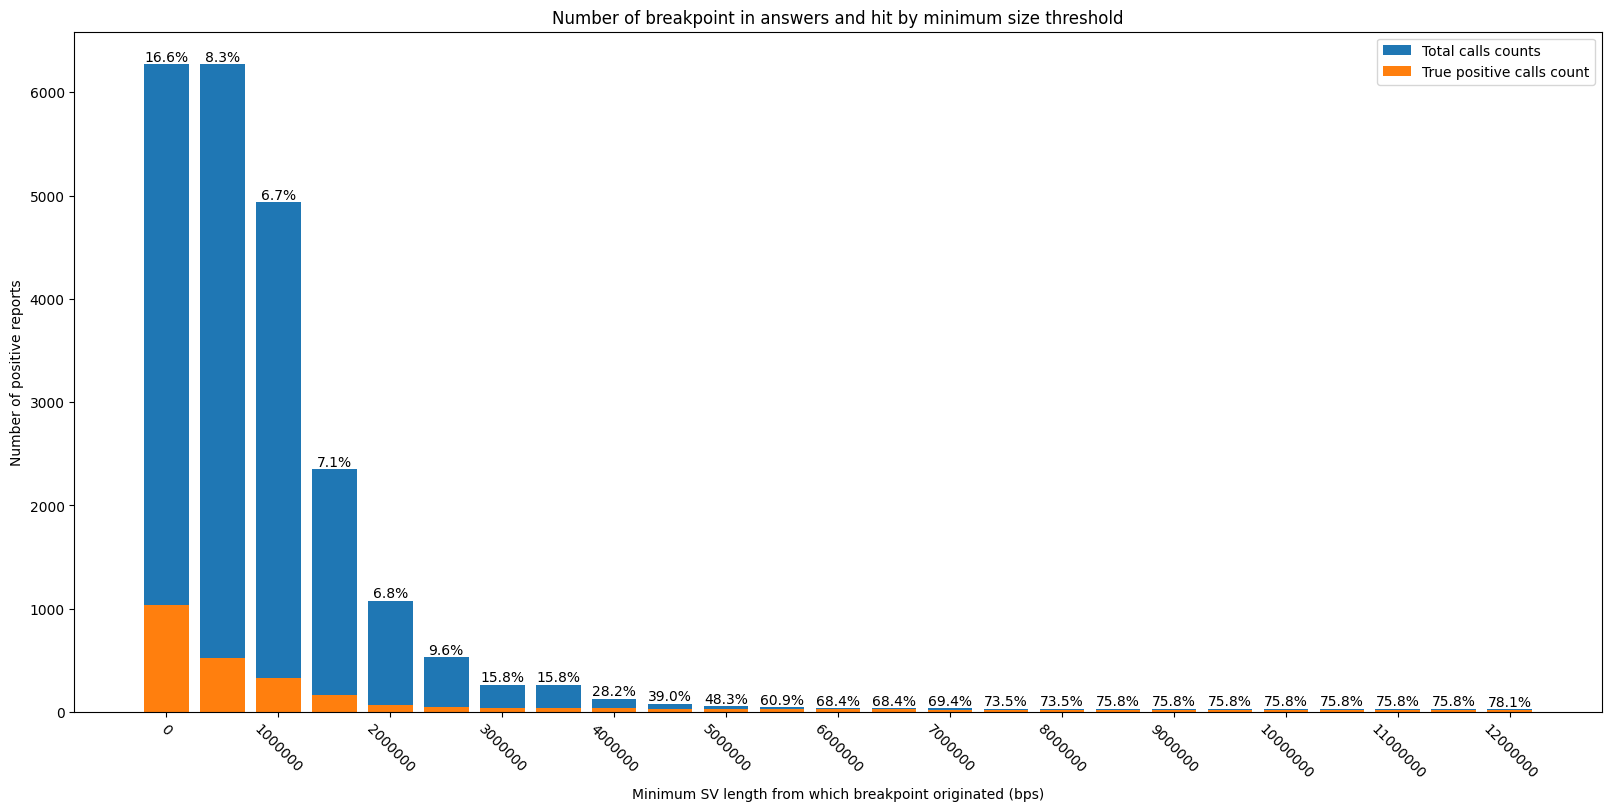

In [53]:
fig, ax = plt.subplots(figsize=(16, 8), layout='constrained')
bars = ax.bar(min_sizes, total_calls_counts, label='Total calls counts')
ax.bar(min_sizes, tps, label='True positive calls count')

ax.bar_label(bars, labels=[f'{tp/total*100:.1f}%' for total, tp in zip(total_calls_counts, tps)])


min_sizes_ticks = min_sizes[::2]
ax.set_xticks(min_sizes_ticks)
ax.set_xticklabels([t*step for t in min_sizes_ticks], rotation=-45)
ax.set_title('Number of breakpoint in answers and hit by minimum size threshold')
ax.set_xlabel('Minimum SV length from which breakpoint originated (bps)')
ax.set_ylabel('Number of positive reports')

plt.legend()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5), layout='constrained')

answers = pd.read_csv(f"{local_path}data/apes/Gor_Chm_SVs.csv")

step = 100000
i=0
counts = []
sv_count = answers.shape[0]
min_sizes = []
while sv_count > 10:
    sv_count = sum(np.abs(answers['start'] - answers['end']) > i*step)
    counts.append(sv_count)
    min_sizes.append(i)
    i+=1

ax.bar(min_sizes, counts)
min_sizes_ticks = min_sizes[::5]
ax.set_xticks(min_sizes_ticks)
ax.set_xticklabels([t*step for t in min_sizes_ticks], rotation=-45)
ax.set_title('Number of SVs in answers by minimum size threshold')
plt.show()

41

In [ ]:
table_dict = {}
table_dict['Label'] = []
table_dict['Accuracy'] = []
table_dict['Recall'] = []
table_dict['Precision'] = []
table_dict['F1'] = []
losses = {}
for label, path in zip((),
                           (f'{local_path}logs/january_logs/chm_gor_train_val_gor_normmat_two_maps_wm_15kb.log',
                            f'{local_path}logs/january_logs/chm_gor_train_val_gor_normmat_two_maps_wm_25kb.log',
                            f'{local_path}logs/january_logs/chm_gor_train_val_gor_normmat_two_maps_wm_50kb.log')):
    with open(path) as file:
        counter = 0
        tp = []
        tn = []
        fp = []
        fn = []
        loss = []
        if not '50kb' in label:
            continue
        for line in file:
            if counter == 6:
                tp.append(int(line.strip().removeprefix('tp ')))
                counter-=1
                continue
            if counter == 5:
                tn.append(int(line.strip().removeprefix('tn ')))
                counter-=1
                continue
            if counter == 4:
                fp.append(int(line.strip().removeprefix('fp ')))
                counter-=1
                continue
            if counter == 3:
                fn.append(int(line.strip().removeprefix('fn ')))
                counter-=1
                continue
            if counter == 2:
                counter-=1
                continue
            if counter == 1:
                loss.append(float(line.split(', ')[0].strip().removeprefix('test loss: ')))
                counter-=1
                continue
            if 'For test metrics are:' in line:
                counter = 6
    tp = tp[-1]
    tn = tn[-1]
    fp = fp[-1]
    fn = fn[-1]
    acc = round((tp+tn)/(tp+tn+fp+fn), 2)
    recall = round(tp/(tp+fn), 2)
    precision = round(tp/(tp+fp), 2)
    f1 = round((2*(tp/(tp+fp))*(tp/(tp+fn)))/((tp/(tp+fp))+(tp/(tp+fn))), 2)

    table_dict['Label'].append(label)
    table_dict['Accuracy'].append(acc)
    table_dict['Recall'].append(recall)
    table_dict['Precision'].append(precision)
    table_dict['F1'].append(f1)

    losses[label] = loss

table = pd.DataFrame(table_dict)
table.to_excel(f'{local_path}logs/december_logs/stats_test.xlsx', index=False)

fig = plt.figure()
ax = plt.subplot(111)
for label, loss in losses.items():
    ax.plot(loss, label=label)
ax.legend(loc='center right', bbox_to_anchor=(1.52, 0.7))


# Precision recall plots

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Tuple, Optional
import matplotlib as mpl
from matplotlib.colors import Normalize
import matplotlib.lines as mlines

# Set publication-quality style
plt.style.use('default')
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.linewidth'] = 1.2
mpl.rcParams['axes.edgecolor'] = 'black'
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True

def calculate_f1(precision: float, recall: float) -> float:
    """Calculate F1 score from precision and recall."""
    if precision + recall == 0:
        return 0
    return 2 * (precision * recall) / (precision + recall)

def create_f1_contour_plot(
    precision_values_groups: List[List[float]],
    recall_values_groups: List[List[float]],
    colors:list[str],
    names:list[str],
    group_names:list[str],
    shapes:list[str],
    figsize: Tuple[float, float] = (8, 6),
    save_path: Optional[str] = None,
    dpi: int = 300,
    title: str = "Precision-Recall Curve with F1 Contours",
    x_label: str = "Recall",
    y_label: str = "Precision",
    show_f1_curves: bool = True,
    f1_levels: List[float] = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    cmap: str = 'plasma',
    marker_size: float = 80,
    font_size_labels: int = 9,
    show_colorbar: bool = True
) -> plt.Figure:
    """
    Create a precision-recall plot with F1-score contour lines and color-coded points.
    
    Parameters:
    -----------
    precision_values : List[float]
        List of precision values
    recall_values : List[float]
        List of recall values
    figsize : Tuple[float, float]
        Figure size (width, height) in inches
    save_path : str, optional
        Path to save the figure
    dpi : int
        Resolution for saved figure
    title : str
        Plot title
    x_label : str
        X-axis label
    y_label : str
        Y-axis label
    show_f1_curves : bool
        Whether to show F1 contour lines
    f1_levels : List[float]
        F1 values for contour lines
    cmap : str
        Colormap for points
    marker_size : float
        Size of markers
    font_size_labels : int
        Font size for F1 value labels
    show_colorbar : bool
        Whether to show colorbar
    
    Returns:
    --------
    plt.Figure
        The matplotlib figure object
    """
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    max_precision =  max(map(max, precision_values_groups))
    max_recall =  max(map(max, recall_values_groups))
    # Plot F1 contour lines if requested
    if show_f1_curves:
        # Create meshgrid for contour lines
        recall_range = np.linspace(0, max_recall * 1.1, 100)
        precision_range = np.linspace(0, max_precision * 1.1, 100)
        R, P = np.meshgrid(recall_range, precision_range)
        
        # Calculate F1 for meshgrid
        F1 = 2 * (P * R) / (P + R)
        F1 = np.where(np.isinf(F1), 0, F1)  # Handle division by zero
        
        # Plot contour lines
        contour = ax.contour(R, P, F1, levels=f1_levels, 
                           colors='gray', linestyles='--', linewidths=1.0, alpha=0.5)
        
        # Add labels to contour lines
        ax.clabel(contour, inline=True, fontsize=8, fmt='F1=%.1f')
    scatter_list = []
    for recall_values, precision_values, shape in zip(recall_values_groups, precision_values_groups, shapes):
        # Scatter plot with color-coded points
        scatter = ax.scatter(recall_values, precision_values, 
                            c=colors, s=marker_size, 
                            edgecolors='black', linewidth=1.0, zorder=5,
                            marker=shape, alpha=0.8)
        scatter_list.append(scatter)
        f1_scores = [calculate_f1(p, r) for p, r in zip(precision_values, recall_values)]

        # Add F1 value labels near each point
        for i, (rec, prec, f1, color) in enumerate(zip(recall_values, precision_values, f1_scores, colors)):
            # Determine label position offset based on point location
            offset_x = 0.02 * max(recall_values)
            offset_y = 0.02 * max(precision_values)
            
            # Adjust offset to avoid labels overlapping
            if i < 2:
                ax.annotate(f'{f1:.2f}', (rec, prec), 
                        xytext=(rec + offset_x, prec + offset_y),
                        fontsize=font_size_labels, 
                        bbox=dict(boxstyle="round,pad=0.2", color=color, alpha=0.8, edgecolor='none'),
                        zorder=6)
            else:
                ax.annotate(f'{f1:.2f}', (rec, prec), 
                        xytext=(rec - offset_x * 2, prec - offset_y * 2),
                        fontsize=font_size_labels,
                        bbox=dict(boxstyle="round,pad=0.2", color=color, alpha=0.8, edgecolor='none'),
                        zorder=6)
    
    # Customize plot appearance
    ax.set_xlabel(x_label, fontweight='normal', fontsize=12)
    ax.set_ylabel(y_label, fontweight='normal', fontsize=12)
    ax.set_title(title, fontweight='normal', fontsize=13, pad=15)

    # Set axis limits with padding
    ax.set_xlim(-0.1, max_recall * 1.15 if max_recall > 0 else 1)
    ax.set_ylim(-0.025, max_precision * 1.15 if max_precision > 0 else 1)
    
    # Tick customization
    ax.tick_params(axis='both', which='major', labelsize=10, length=4)
    
    legend_items = []
    for group_name, shape in zip(group_names, shapes):
        for color, name in zip(colors, names):
            new_item = mlines.Line2D([], [], color=color, marker=shape, linestyle='None',
                            markersize=10, label=group_name+' '+name)
            legend_items.append(new_item)

    plt.legend(handles=legend_items, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    # Adjust layout
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
    
    return fig


In [42]:
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Tuple, Optional
import matplotlib as mpl
import matplotlib.lines as mlines

# Style
plt.style.use('default')
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.linewidth'] = 1.2
mpl.rcParams['axes.edgecolor'] = 'black'
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True


def calculate_f1(precision: float, recall: float) -> float:
    if precision + recall == 0:
        return 0
    return 2 * (precision * recall) / (precision + recall)


def create_f1_contour_plot_group_by_shape(
    precision_values_groups: List[List[float]],
    recall_values_groups: List[List[float]],
    colors: List[str],         # per group
    names: List[str],          # per point (methods)
    group_names: List[str],
    shapes: List[str],         # per point (methods)
    figsize: Tuple[float, float] = (8, 6),
    save_path: Optional[str] = None,
    dpi: int = 300,
    title: str = "Precision-Recall Curve with F1 Contours",
    x_label: str = "Recall",
    y_label: str = "Precision",
    show_f1_curves: bool = True,
    f1_levels: List[float] = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    marker_size: float = 80,
    font_size_labels: int = 9
) -> plt.Figure:

    fig, ax = plt.subplots(figsize=figsize)

    max_precision = max(map(max, precision_values_groups))
    max_recall = max(map(max, recall_values_groups))

    # ---- F1 contour lines ----
    if show_f1_curves:
        recall_range = np.linspace(0, max_recall * 1.1, 100)
        precision_range = np.linspace(0, max_precision * 1.1, 100)
        R, P = np.meshgrid(recall_range, precision_range)

        F1 = 2 * (P * R) / (P + R)
        F1 = np.where(np.isinf(F1), 0, F1)

        contour = ax.contour(
            R, P, F1,
            levels=f1_levels,
            colors='gray',
            linestyles='--',
            linewidths=1.0,
            alpha=0.5
        )
        ax.clabel(contour, inline=True, fontsize=8, fmt='F1=%.1f')

    # ---- Scatter points (FIXED LOGIC) ----
    for group_idx, (recall_values, precision_values, group_color, group_name) in enumerate(
            zip(recall_values_groups, precision_values_groups, colors, group_names)):

        for i, (rec, prec, shape, name) in enumerate(zip(recall_values, precision_values, shapes, names)):

            ax.scatter(
                rec, prec,
                color=group_color,      # color = group
                marker=shape,           # shape = method
                s=marker_size,
                edgecolors='black',
                linewidth=1.0,
                zorder=5,
                alpha=0.8
            )

            # ---- F1 annotation ----
            f1 = calculate_f1(prec, rec)

            offset_x = 0.02 * max(recall_values)
            offset_y = 0.02 * max(precision_values)

            if i < 2:
                xytext = (rec + offset_x, prec + offset_y)
            else:
                xytext = (rec - offset_x * 2, prec - offset_y * 2)

            ax.annotate(
                f'{f1:.2f}', (rec, prec),
                xytext=xytext,
                fontsize=font_size_labels,
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    color=group_color,
                    alpha=0.8,
                    edgecolor='none'
                ),
                zorder=6
            )

    # ---- Axis formatting ----
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_title(title, fontsize=13, pad=15)

    ax.set_xlim(-0.1, max_recall * 1.15 if max_recall > 0 else 1)
    ax.set_ylim(-0.025, max_precision * 1.15 if max_precision > 0 else 1)

    ax.tick_params(axis='both', which='major', labelsize=10, length=4)

    # ---- Legends ----

    # Groups (colors)
    group_handles = [
        mlines.Line2D([], [], color=color, marker='o', linestyle='None',
                      markersize=10, label=group_name)
        for color, group_name in zip(colors, group_names)
    ]

    legend1 = ax.legend(
        handles=group_handles,
        title="Tools",
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )
    ax.add_artist(legend1)

    # Methods (shapes)
    shape_handles = [
        mlines.Line2D([], [], color='black', marker=shape, linestyle='None',
                      markersize=10, label=name)
        for shape, name in zip(shapes, names)
    ]

    ax.legend(
        handles=shape_handles,
        title="Ape species",
        bbox_to_anchor=(1.05, 0.6),
        loc='upper left'
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none'
        )

    return fig

C:\Users\vit\AppData\Local\Temp\ipykernel_15992\1330990397.py:58: RuntimeWarning: invalid value encountered in divide
  F1 = 2 * (P * R) / (P + R)
C:\Users\vit\AppData\Local\Temp\ipykernel_15992\1330990397.py:99: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate(


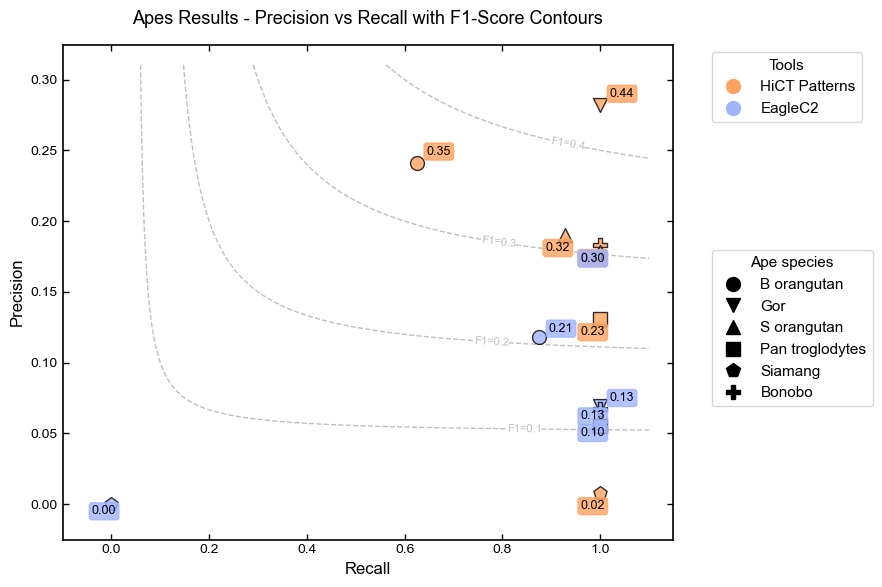

In [44]:
labels = list(mono_results['pipeline'].keys())
pipeline_recalls = []
eaglec_recalls = []
pipeline_precisions = []
eaglec_precisions = []

for label in labels:
    pipeline_recall = mono_results['pipeline'][label]['recall']
    eaglec_recall = mono_results['eaglec'][label]['recall']
    pipeline_precision = mono_results['pipeline'][label]['precision']
    eaglec_precision = mono_results['eaglec'][label]['precision']
    pipeline_recalls.append(pipeline_recall)
    eaglec_recalls.append(eaglec_recall)
    pipeline_precisions.append(pipeline_precision)
    eaglec_precisions.append(eaglec_precision)

fig = create_f1_contour_plot_group_by_shape(
    precision_values_groups=[pipeline_precisions, eaglec_precisions],
    recall_values_groups=[pipeline_recalls, eaglec_recalls],
    colors=['#ffa360', "#a0b4ff", ],
    shapes=['o', 'v', '^', 's', 'p', 'P'],
    names=labels,
    group_names=['HiCT Patterns', 'EagleC2'],
    figsize=(9, 6),
    title=f"Apes Results - Precision vs Recall with F1-Score Contours",
    x_label="Recall",
    y_label="Precision",
    show_f1_curves=True,
    f1_levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 0.9, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
    marker_size=100,
    font_size_labels=9,
)

# Show the plot
plt.savefig('mono_results.svg')
plt.show()


### Gor

C:\Users\vit\AppData\Local\Temp\ipykernel_16580\1747905418.py:103: RuntimeWarning: invalid value encountered in divide
  F1 = 2 * (P * R) / (P + R)


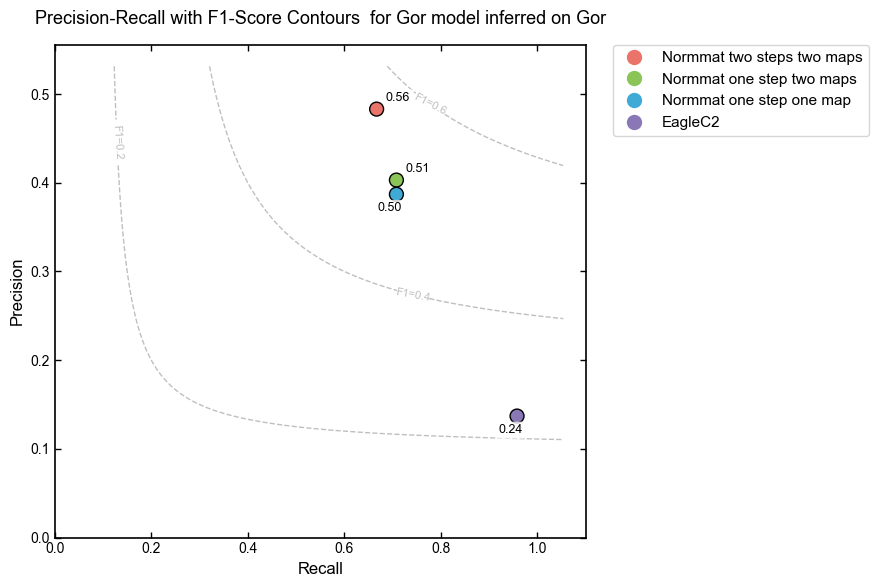

In [6]:

#Normmat two steps two maps, Normmat one step two maps, Normmat one step one map, EagleC2
fig = create_f1_contour_plot(
        precision_values=[0.483, 0.403, 0.387,  0.137],
        recall_values=[0.667, 0.708, 0.708, 0.958],
        colors=['#ea746a', '#8bc557', '#3faad6', '#8a78b6'],
        names=['Normmat two steps two maps', 'Normmat one step two maps', 'Normmat one step one map', 'EagleC2'],
        figsize=(9, 6),
        title="Precision-Recall with F1-Score Contours  for Gor model inferred on Gor",
        x_label="Recall",
        y_label="Precision",
        show_f1_curves=True,
        f1_levels=[0.2, 0.4, 0.6, 0.8, 0.9, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
        cmap='viridis',
        marker_size=100,
        font_size_labels=9,
        show_colorbar=True
    )

# Show the plot
plt.show()

### PanPan

C:\Users\vit\AppData\Local\Temp\ipykernel_16580\1747905418.py:103: RuntimeWarning: invalid value encountered in divide
  F1 = 2 * (P * R) / (P + R)


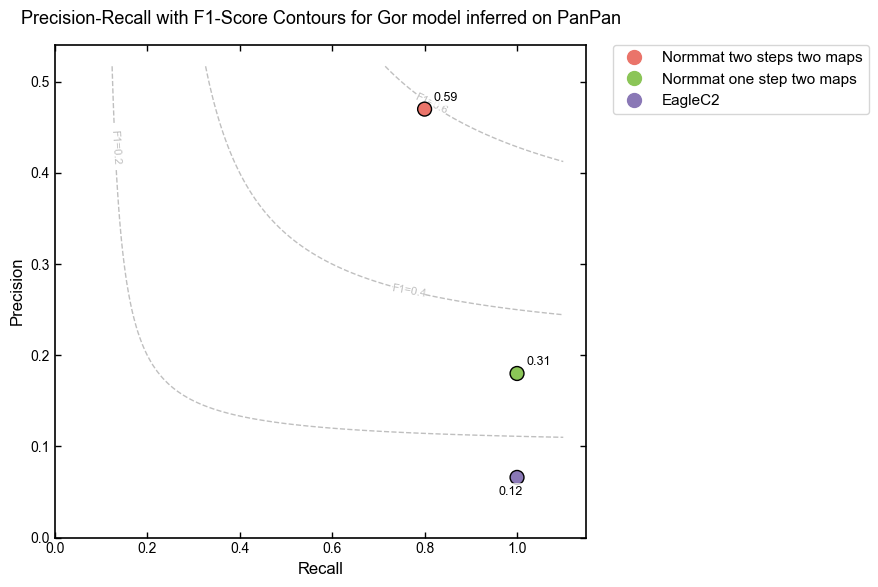

In [7]:
#Normmat two steps two maps, Normmat one step two maps, EagleC2
fig = create_f1_contour_plot(
        precision_values=[0.47, 0.18,  0.066],
        recall_values=[0.8 ,1 ,1 ],
        colors=['#ea746a', '#8bc557', '#8a78b6'],
        names=['Normmat two steps two maps', 'Normmat one step two maps', 'EagleC2'],
        figsize=(9, 6),
        title="Precision-Recall with F1-Score Contours for Gor model inferred on PanPan",
        x_label="Recall",
        y_label="Precision",
        show_f1_curves=True,
        f1_levels=[0.2, 0.4, 0.6, 0.8, 0.9, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
        cmap='viridis',
        marker_size=100,
        font_size_labels=9,
        show_colorbar=True
    )

# Show the plot
plt.show()

## Validation on symulated data

In [46]:
import os
import pandas as pd

# Directory with your files
data_dir = "E:\Study\HICT_Patterns\logs\pipeline_results\simulated_validation"

results = []

for filename in os.listdir(data_dir):
    if filename.endswith(".txt"):
        filepath = os.path.join(data_dir, filename)
        
        # Extract label from filename (customize if needed)
        # Example: validate_symulated_Bonobo_1.txt -> Bonobo_1
        label = filename.replace("validate_simulated_", "").replace(".txt", "")
        
        metrics = {}
        
        # Parse file
        with open(filepath, "r") as f:
            for line in f:
                key, value = line.strip().split(",")
                metrics[key] = int(value)
        
        tp = metrics.get("tp", 0)
        fp = metrics.get("fp", 0)
        fn = metrics.get("fn", 0)
        
        # Compute metrics safely
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        results.append({
            "label": label,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall
        })

# Create DataFrame
df = pd.DataFrame(results)

# Optional: sort by label
df = df.sort_values("label").reset_index(drop=True)

df

<>:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\vit\AppData\Local\Temp\ipykernel_15992\3334327155.py:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  data_dir = "E:\Study\HICT_Patterns\logs\pipeline_results\simulated_validation"


,label,tp,fp,fn,precision,recall
0,B_orangutan_1,152,8,30,0.950000,0.835165
1,B_orangutan_2,108,9,167,0.923077,0.392727
2,Bonobo_1,151,6,31,0.961783,0.829670
3,Bonobo_2,106,5,169,0.954955,0.385455
4,Gor_1,136,2,46,0.985507,0.747253
5,Gor_2,251,64,24,0.796825,0.912727
6,Pan_troglodytes_1,170,12,12,0.934066,0.934066
7,S_orangutan_1,152,9,30,0.944099,0.835165
8,S_orangutan_2,103,9,172,0.919643,0.374545
9,Siamang_1,158,7,24,0.957576,0.868132


In [2]:
tp =  23276
tn =  30416
fp =  3440
fn =  10580

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
print(precision)
print(recall)
print(f1)

0.8712382093127714
0.6875
0.7685399194347222


In [1]:
tp= 11
tn= 15
fp= 1
fn= 5

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
print(precision)
print(recall)
print(f1)

0.9166666666666666
0.6875
0.7857142857142857


C:\Users\vit\AppData\Local\Temp\ipykernel_15992\3504204079.py:100: RuntimeWarning: invalid value encountered in divide
  F1 = 2 * (P * R) / (P + R)
C:\Users\vit\AppData\Local\Temp\ipykernel_15992\3504204079.py:127: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate(f'{f1:.2f}', (rec, prec),
C:\Users\vit\AppData\Local\Temp\ipykernel_15992\3504204079.py:133: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate(f'{f1:.2f}', (rec, prec),


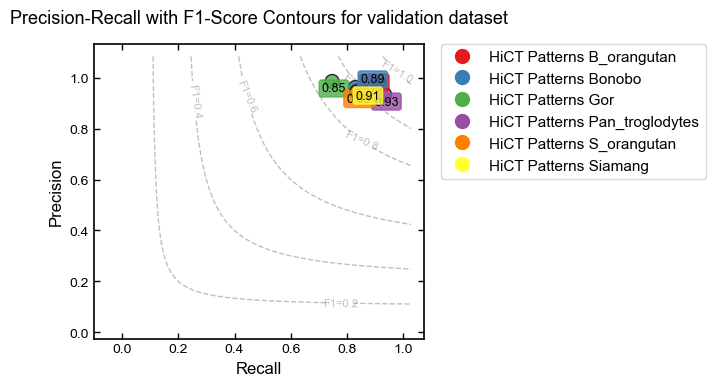

In [17]:
fig = create_f1_contour_plot(
        precision_values_groups=[df.precision, ],
        recall_values_groups=[ df.recall, ],
        colors=['#e41a1c', "#377eb8",'#4daf4a', '#984ea3', '#ff7f00', '#ffff33', ],
        names=df.label,
        figsize=(7, 4),
        shapes=['o'],
        group_names=['HiCT Patterns'],
        title="Precision-Recall with F1-Score Contours for validation dataset",
        x_label="Recall",
        y_label="Precision",
        show_f1_curves=True,
        f1_levels=[0.2, 0.4, 0.6, 0.8, 0.9, 1.0],
        cmap='viridis',
        marker_size=100,
        font_size_labels=9,
        show_colorbar=True
    )

# Show the plot
plt.savefig('simulated_results.svg')
plt.show()